In [1]:
import pandas as pd
import os
pd.set_option('display.max_columns', 500)


In [22]:
df = pd.read_csv("/home/chinemelu/AfriMed-QA/data/afri_med_qa_15k_v2.5_phase_2_15275.csv")

In [23]:
df_289 = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gpt-4/afrimed-qa-v2-5_gpt-4_mcq_base-prompt__0-shot_score_0.7993_289.csv")
df_39 = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gpt-4/gpt-4_mcq_afrimed-qa-v2_base-prompt__no_exp_0-shot_score_0.7568_3910.csv")

In [24]:
all = set(df_39['sample_id'].tolist())
row_289 = set(df_289['sample_id'].tolist())
non_af = list(all.difference(row_289))
len(non_af)


3750

In [25]:
def processs_data(df1):
    df1['correct_ct'] = df1['correct'].apply(lambda x: 1 if x == True else 0)
    df_m = df1[df1['sample_id'].isin(non_af)].reset_index(drop=True)
    df_m1 = df1[df1['sample_id'].isin(row_289)].reset_index(drop=True)
    
    return df_m1, df_m

In [26]:
df=pd.read_csv("/home/chinemelu/AfriMed-QA/data/afri_med_qa_15k_v2.5_phase_2_15275.csv")
df['correct_answer2'] = df['correct_answer'].str.replace('option1', 'A').str.replace('option2', 'B').str.replace('option3', 'C').str.replace('option4', 'D').str.replace('option5', 'E')

In [27]:
df.shape

(15275, 31)

In [13]:
df.columns

Index(['sample_id', 'split', 'gender', 'discipline', 'clinical_experience',
       'country', 'question_type', 'prompt', 'question', 'question_clean',
       'answer_options', 'correct_answer', 'answer_rationale', 'specialty',
       'region_specific', 'mentions_Africa', 'mentions_age', 'mentions_gender',
       'tier', 'neg_percent', 'quality', 'rated_african', 'rated_correct',
       'rated_omission', 'rated_hallucination', 'rated_reasonable',
       'rated_harmful', 'rated_bias', 'version', 'requires_african_expertise',
       'correct_answer2'],
      dtype='object')

In [14]:
df['tier'].unique()

array(['crowdsourced', 'expert'], dtype=object)

In [15]:
df1 = pd.read_csv('/home/chinemelu/AfriMed-QA/afri_results/claude-3-7-sonnet_0.7435_3910.csv')
df39 = df1[['sample_id']]
df39.shape

(3910, 1)

In [16]:
df['correct_answer2'].value_counts()

correct_answer2
C            877
B            829
D            805
A            775
E            438
B,D           20
B,C,D         19
B,C           18
A,B,C         15
C,D,E         15
A,D           14
B,D,E         14
A,C,E         14
A,B,C,D,E     14
A,B,C,D       13
A,C,D         13
C,D           12
B,C,D,E       12
A,C           12
A,C,D,E       11
B,C,E         11
A,B,D,E       11
A,E           10
A,B,C,E       10
A,B,D         10
B,E            9
D,E            9
A,D,E          8
A,B,E          8
C,E            7
A,B            6
Name: count, dtype: int64

In [17]:
def calculate_score(row):
    correct = row['correct_answer2']
    model = row['preds']

    # Handle NoneType values
    if pd.isna(correct) and pd.isna(model):
        return 0
    if pd.isna(correct) or pd.isna(model):
        return 0
    
    # Split 'correct answer' into a set for comparison
    correct_set = set(correct.split(','))
    # Check if 'model answer' is in the correct set
    if model in correct_set:
        return 1
    return 0

In [3]:
def calculate_score2(row):
    correct = row['correct_answer2']
    model   = row['preds']

    # Handle None / NaN
    if pd.isna(correct) or pd.isna(model):
        return 0

    # Turn both into sets
    correct_set = set(correct.split(','))
    model_set   = set(model.split(','))

    # If there's any overlap, score = 1
    return int(bool(correct_set & model_set))


In [1]:
def processs_data2(df2):
    df1 = df2.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')
    df1.rename(columns={'correct_answer_x': "correct_answer", "specialty_x" : "specialty", "country_x" : "country", "selected_option" : "preds"},inplace=True)
    # df1['answer'] = df39_m['answer']

    df1['preds'] = df1['preds'].replace({
    'option1': 'A',
    'option2': 'B',
    'option3': 'C',
    'option4': 'D',
    'option5': 'E'
    }) 

    df1['correct'] = df1.apply(calculate_score, axis=1)
    avr = round(df1['correct'].mean(),6)

    sc = []

    for i in range(len(df1)):
        if df1['correct'][i] == True:
            x = 1
        else:
            x = 0
        sc.append(x)

    df1['score'] = sc


    df3 = df1.groupby('specialty').agg({'specialty':'count','score':'sum'})
    df3['score'] = round(df3['score']/df1['specialty'],2)
    #avr = df1['score'].mean()
    return df3,avr,df1

In [17]:
specs = df['specialty'].unique()
specs_df = pd.DataFrame(specs, columns=['specialty'])

model_scores = pd.DataFrame(columns=['model','score'])

models = []
scores = []



# Define the root directory where subdirectories are located
root_dir = "/home/chinemelu/AfriMed-QA/afri_results"


# Walk through each subdirectory in the root directory
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('3910.csv'):
            file_path = os.path.join(subdir, file)
            # Read the CSV file and append it to the list
            df1 = pd.read_csv(file_path)
            df2 = processs_data2(df1)[0]
            avr = processs_data2(df1)[1]
            print(f"{file.split('\\')[-1].split('_')[0]}:{avr}")
            df2.rename(columns={'score':file_path.split('\\')[-1].split('_')[0]},inplace=True)
            df2.drop(columns=['specialty'],inplace=True)
            df2.reset_index(inplace=True)
            specs_df = specs_df.merge(df2,on='specialty',how='outer')
            specs_df.set_index('specialty',inplace=True)

            models.append(f"{file_path.split('\\')[-1].split('_')[0]}")
            scores.append(avr)
model_scores['model'] = models
model_scores['score'] = scores 

llama3-405b-instruct-maas:0.800767
Meta-Llama-3-8B:0.504348
claude-3-7-sonnet:0.782864
gemini-pro-1.5:0.634015


MergeError: Passing 'suffixes' which cause duplicate columns {'/home/chinemelu/AfriMed-QA/afri_x'} is not allowed.

In [276]:
specs = df['specialty'].unique()
specs_df = pd.DataFrame(specs, columns=['specialty'])

model_scores = pd.DataFrame(columns=['model','score'])

models = []
scores = []



# Define the root directory where subdirectories are located
root_dir = "\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\afri results"


# Walk through each subdirectory in the root directory
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(subdir, file)
            # Read the CSV file and append it to the list
            df1 = pd.read_csv(file_path)
            df2 = processs_data2(df1)[0]
            avr = processs_data2(df1)[1]
            print(f"{file_path.split('\\')[-1].split('_')[0]}:{avr}")
            df2.rename(columns={'score':file_path.split('\\')[-1].split('_')[0]},inplace=True)
            df2.drop(columns=['specialty'],inplace=True)
            df2.reset_index(inplace=True)
            specs_df = specs_df.merge(df2,on='specialty',how='outer')
            specs_df.set_index('specialty',inplace=True)

            models.append(f"{file_path.split('\\')[-1].split('_')[0]}")
            scores.append(avr)
model_scores['model'] = models
model_scores['score'] = scores    
    

<>:12: SyntaxWarning: invalid escape sequence '\E'
<>:12: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Ezinwanne\AppData\Local\Temp\ipykernel_27584\2473403749.py:12: SyntaxWarning: invalid escape sequence '\E'
  root_dir = "\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\afri results"


claude-3-5-sonnet:0.815857
claude-3-7-sonnet:0.782864
claude-3-haiku:0.703069
claude-3-opus:0.785166
claude-3-sonnet:0.68798
deepseek-distill-qwen32b:0.469821
gemini-2.0-flash:0.756522
gemini-2.0-pro-exp:0.754987
gemini-pro-1.5:0.634015
gemini-ultra:0.779284
gemma-3-27b-it:0.709207
gemma2-27b:0.596675
gemma2-2b:0.362916
gemma2-9b:0.568798
gpt-3.5-turbo:0.591816
gpt-4o-mini:0.743734
gpt-4o:0.8289
gpt-4:0.789258
JSL-MedLlama-3-8B-v2.0:0.60179
Llama-3.3-70B:0.736829
llama-4-maverick-17b-128e-it:0.743223
llama3-405b-instruct-maas:0.800767
Llama3-OpenBioLLM-70B:0.643734
Llama3-OpenBioLLM-8B:0.477761
meditron:0.536317
Meta-Llama-3-70B-Instruct:0.774936
Meta-Llama-3-8B:0.504348
Meta-Llama-3.1-8B-Instruct:0.653964
Mistral-7B-Instruct-v0.2:0.511765
Mistral-7B-Instruct-v0.3:0.53734
Mixtral-8x7B-Instruct-v0.1:0.641176


KeyError: 'sample_id'

In [237]:
model_scores

,model,score
0,claude-3-5-sonnet,0.81586
1,claude-3-7-sonnet,0.78286
2,claude-3-haiku,0.70307
3,claude-3-opus,0.78517
4,claude-3-sonnet,0.68798
5,deepseek-distill-qwen32b,0.46982
6,gemini-2.0-flash,0.75652
7,gemini-2.0-pro-exp,0.75499
8,gemini-pro-1.5,0.63402
9,gemini-ultra,0.77928


In [238]:
model_scores.to_csv("model_scores.csv")

In [239]:
specs_df

,claude-3-5-sonnet,claude-3-7-sonnet,claude-3-haiku,claude-3-opus,claude-3-sonnet,deepseek-distill-qwen32b,gemini-2.0-flash,gemini-2.0-pro-exp,gemini-pro-1.5,gemini-ultra,gemma-3-27b-it,gemma2-27b,gemma2-2b,gemma2-9b,gpt-3.5-turbo,gpt-4o-mini,gpt-4o,gpt-4,JSL-MedLlama-3-8B-v2.0,Llama-3.3-70B,llama-4-maverick-17b-128e-it,llama3-405b-instruct-maas,Llama3-OpenBioLLM-70B,Llama3-OpenBioLLM-8B,meditron,Meta-Llama-3-70B-Instruct,Meta-Llama-3-8B,Meta-Llama-3.1-8B-Instruct,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.3,Mixtral-8x7B-Instruct-v0.1,o1,Phi-3-medium-128k-instruct,Phi-3-mini-128k-instruct,Phi-3-mini-4k-instruct,phi-4-mini-4k-instruct,phi4,pmc,qwen-2.5-32b
specialty,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Allergy_and_Immunology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Anesthesiology,1.00,1.00,0.75,0.92,0.75,0.58,0.92,0.92,0.83,0.92,0.67,0.67,0.25,0.83,0.58,0.75,1.00,1.00,0.75,0.75,0.92,1.00,0.75,0.42,0.50,0.92,0.58,0.75,0.75,0.67,0.75,1.00,0.83,0.83,0.75,0.75,0.75,0.50,0.75
Cardiology,0.83,0.81,0.72,0.77,0.69,0.43,0.80,0.81,0.60,0.80,0.72,0.59,0.28,0.63,0.59,0.76,0.86,0.83,0.61,0.78,0.75,0.81,0.65,0.45,0.51,0.77,0.47,0.67,0.42,0.49,0.62,0.86,0.70,0.60,0.59,0.53,0.76,0.41,0.70
Communicable_Disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dermatology,0.86,0.76,0.72,0.69,0.66,0.28,0.76,0.76,0.72,0.83,0.66,0.59,0.38,0.69,0.62,0.79,0.86,0.83,0.62,0.69,0.72,0.76,0.66,0.45,0.55,0.76,0.72,0.76,0.48,0.55,0.55,0.83,0.69,0.48,0.55,0.45,0.76,0.52,0.72
Emergency_Medicine,0.83,0.78,0.74,0.74,0.83,0.43,0.65,0.70,0.61,0.70,0.78,0.74,0.43,0.65,0.61,0.70,0.91,0.78,0.48,0.74,0.96,0.83,0.74,0.35,0.52,0.61,0.57,0.52,0.61,0.61,0.70,0.87,0.74,0.78,0.78,0.70,0.65,0.61,0.78
Endocrinology,0.91,0.87,0.80,0.88,0.79,0.54,0.83,0.86,0.71,0.82,0.80,0.69,0.40,0.65,0.67,0.80,0.90,0.86,0.72,0.82,0.82,0.90,0.77,0.57,0.58,0.85,0.56,0.74,0.50,0.50,0.71,0.92,0.77,0.69,0.70,0.65,0.78,0.56,0.77
Family_Medicine,0.60,0.60,0.80,0.60,0.80,0.00,0.80,0.60,0.80,0.60,0.80,0.40,0.80,0.60,0.80,0.80,0.80,0.80,0.80,0.60,0.60,0.60,0.40,0.40,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.60,0.80,0.80,0.80,0.60,0.60,0.80,0.60
Gastroenterology,0.91,0.87,0.76,0.84,0.72,0.51,0.85,0.82,0.70,0.82,0.77,0.69,0.35,0.70,0.66,0.84,0.91,0.87,0.71,0.87,0.78,0.91,0.73,0.58,0.55,0.85,0.61,0.75,0.52,0.53,0.70,0.95,0.79,0.60,0.63,0.58,0.85,0.53,0.78


In [240]:
spec_o = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\spec_df_full_mcq_experts.csv")

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Ezinwanne\AppData\Local\Temp\ipykernel_27584\634620374.py:1: SyntaxWarning: invalid escape sequence '\E'
  spec_o = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\spec_df_full_mcq_experts.csv")


In [241]:
spec_o = spec_o[['specialty']]

In [242]:
spec_o

,specialty
0,Anesthesiology
1,Cardiology
2,Dermatology
3,Emergency_Medicine
4,Endocrinology
5,Family_Medicine
6,Gastroenterology
7,General_Surgery
8,Geriatrics
9,Hematology


In [243]:
specs_df = specs_df.merge(spec_o,on='specialty',how='right')

In [244]:
specs_df

,specialty,claude-3-5-sonnet,claude-3-7-sonnet,claude-3-haiku,claude-3-opus,claude-3-sonnet,deepseek-distill-qwen32b,gemini-2.0-flash,gemini-2.0-pro-exp,gemini-pro-1.5,gemini-ultra,gemma-3-27b-it,gemma2-27b,gemma2-2b,gemma2-9b,gpt-3.5-turbo,gpt-4o-mini,gpt-4o,gpt-4,JSL-MedLlama-3-8B-v2.0,Llama-3.3-70B,llama-4-maverick-17b-128e-it,llama3-405b-instruct-maas,Llama3-OpenBioLLM-70B,Llama3-OpenBioLLM-8B,meditron,Meta-Llama-3-70B-Instruct,Meta-Llama-3-8B,Meta-Llama-3.1-8B-Instruct,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.3,Mixtral-8x7B-Instruct-v0.1,o1,Phi-3-medium-128k-instruct,Phi-3-mini-128k-instruct,Phi-3-mini-4k-instruct,phi-4-mini-4k-instruct,phi4,pmc,qwen-2.5-32b
0,Anesthesiology,1.00,1.00,0.75,0.92,0.75,0.58,0.92,0.92,0.83,0.92,0.67,0.67,0.25,0.83,0.58,0.75,1.00,1.00,0.75,0.75,0.92,1.00,0.75,0.42,0.50,0.92,0.58,0.75,0.75,0.67,0.75,1.00,0.83,0.83,0.75,0.75,0.75,0.50,0.75
1,Cardiology,0.83,0.81,0.72,0.77,0.69,0.43,0.80,0.81,0.60,0.80,0.72,0.59,0.28,0.63,0.59,0.76,0.86,0.83,0.61,0.78,0.75,0.81,0.65,0.45,0.51,0.77,0.47,0.67,0.42,0.49,0.62,0.86,0.70,0.60,0.59,0.53,0.76,0.41,0.70
2,Dermatology,0.86,0.76,0.72,0.69,0.66,0.28,0.76,0.76,0.72,0.83,0.66,0.59,0.38,0.69,0.62,0.79,0.86,0.83,0.62,0.69,0.72,0.76,0.66,0.45,0.55,0.76,0.72,0.76,0.48,0.55,0.55,0.83,0.69,0.48,0.55,0.45,0.76,0.52,0.72
3,Emergency_Medicine,0.83,0.78,0.74,0.74,0.83,0.43,0.65,0.70,0.61,0.70,0.78,0.74,0.43,0.65,0.61,0.70,0.91,0.78,0.48,0.74,0.96,0.83,0.74,0.35,0.52,0.61,0.57,0.52,0.61,0.61,0.70,0.87,0.74,0.78,0.78,0.70,0.65,0.61,0.78
4,Endocrinology,0.91,0.87,0.80,0.88,0.79,0.54,0.83,0.86,0.71,0.82,0.80,0.69,0.40,0.65,0.67,0.80,0.90,0.86,0.72,0.82,0.82,0.90,0.77,0.57,0.58,0.85,0.56,0.74,0.50,0.50,0.71,0.92,0.77,0.69,0.70,0.65,0.78,0.56,0.77
5,Family_Medicine,0.60,0.60,0.80,0.60,0.80,0.00,0.80,0.60,0.80,0.60,0.80,0.40,0.80,0.60,0.80,0.80,0.80,0.80,0.80,0.60,0.60,0.60,0.40,0.40,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.60,0.80,0.80,0.80,0.60,0.60,0.80,0.60
6,Gastroenterology,0.91,0.87,0.76,0.84,0.72,0.51,0.85,0.82,0.70,0.82,0.77,0.69,0.35,0.70,0.66,0.84,0.91,0.87,0.71,0.87,0.78,0.91,0.73,0.58,0.55,0.85,0.61,0.75,0.52,0.53,0.70,0.95,0.79,0.60,0.63,0.58,0.85,0.53,0.78
7,General_Surgery,0.84,0.81,0.73,0.82,0.70,0.44,0.78,0.78,0.64,0.80,0.70,0.57,0.34,0.54,0.58,0.78,0.86,0.80,0.60,0.74,0.77,0.84,0.63,0.43,0.54,0.78,0.48,0.67,0.52,0.50,0.61,0.87,0.70,0.61,0.62,0.54,0.76,0.48,0.72
8,Geriatrics,1.00,0.50,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,1.00,0.50,1.00,0.50,1.00,0.50,0.50,1.00,1.00,0.50,1.00,0.50,1.00,1.00,1.00,1.00,0.50,1.00,1.00,1.00,0.50,1.00
9,Hematology,0.79,0.78,0.70,0.81,0.68,0.53,0.66,0.67,0.62,0.85,0.76,0.17,0.18,0.16,0.66,0.76,0.82,0.83,0.51,0.66,0.73,0.79,0.34,0.41,0.47,0.76,0.51,0.59,0.49,0.52,0.62,0.80,0.72,0.61,0.61,0.56,0.70,0.45,0.52


In [245]:
specs_df.sum().to_frame().drop('specialty').sort_values(by=0,ascending=False).index

Index(['o1', 'gpt-4o', 'claude-3-5-sonnet', 'llama3-405b-instruct-maas',
       'gpt-4', 'Meta-Llama-3-70B-Instruct', 'claude-3-opus', 'gemini-ultra',
       'claude-3-7-sonnet', 'gemini-2.0-flash', 'gemini-2.0-pro-exp',
       'gpt-4o-mini', 'llama-4-maverick-17b-128e-it', 'phi4', 'claude-3-haiku',
       'qwen-2.5-32b', 'Llama-3.3-70B', 'claude-3-sonnet',
       'Phi-3-medium-128k-instruct', 'gemma-3-27b-it',
       'Mixtral-8x7B-Instruct-v0.1', 'Phi-3-mini-4k-instruct',
       'gemini-pro-1.5', 'Meta-Llama-3.1-8B-Instruct',
       'Phi-3-mini-128k-instruct', 'gemma2-27b', 'Llama3-OpenBioLLM-70B',
       'JSL-MedLlama-3-8B-v2.0', 'phi-4-mini-4k-instruct',
       'Mistral-7B-Instruct-v0.3', 'gemma2-9b', 'gpt-3.5-turbo', 'meditron',
       'pmc', 'Mistral-7B-Instruct-v0.2', 'Meta-Llama-3-8B',
       'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b'],
      dtype='object')

In [246]:
cols = ['specialty','o1', 'gpt-4o', 'claude-3-5-sonnet', 'llama3-405b-instruct-maas',
       'gpt-4', 'Meta-Llama-3-70B-Instruct', 'claude-3-opus', 'gemini-ultra',
       'claude-3-7-sonnet', 'gemini-2.0-flash', 'gemini-2.0-pro-exp',
       'gpt-4o-mini', 'llama-4-maverick-17b-128e-it', 'phi4', 'claude-3-haiku',
       'qwen-2.5-32b', 'Llama-3.3-70B', 'claude-3-sonnet',
       'Phi-3-medium-128k-instruct', 'gemma-3-27b-it',
       'Mixtral-8x7B-Instruct-v0.1', 'Phi-3-mini-4k-instruct',
       'gemini-pro-1.5', 'Meta-Llama-3.1-8B-Instruct',
       'Phi-3-mini-128k-instruct', 'gemma2-27b', 'Llama3-OpenBioLLM-70B',
       'JSL-MedLlama-3-8B-v2.0', 'phi-4-mini-4k-instruct',
       'Mistral-7B-Instruct-v0.3', 'gemma2-9b', 'gpt-3.5-turbo', 'meditron',
       'pmc', 'Mistral-7B-Instruct-v0.2', 'Meta-Llama-3-8B',
       'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b'
        ]

In [247]:
specs_df2 = specs_df[cols]

In [ ]:
specs_df2 = specs_df2.set_index('specialty')
specs_df2['sum']= specs_df2.sum(axis=1)
specs_df3 = specs_df2.sort_values(by='sum', ascending=False).drop('sum', axis=1)

In [249]:
specs_df3

,o1,gpt-4o,claude-3-5-sonnet,llama3-405b-instruct-maas,gpt-4,Meta-Llama-3-70B-Instruct,claude-3-opus,gemini-ultra,claude-3-7-sonnet,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,phi4,claude-3-haiku,qwen-2.5-32b,Llama-3.3-70B,claude-3-sonnet,Phi-3-medium-128k-instruct,gemma-3-27b-it,Mixtral-8x7B-Instruct-v0.1,Phi-3-mini-4k-instruct,gemini-pro-1.5,Meta-Llama-3.1-8B-Instruct,Phi-3-mini-128k-instruct,gemma2-27b,Llama3-OpenBioLLM-70B,JSL-MedLlama-3-8B-v2.0,phi-4-mini-4k-instruct,Mistral-7B-Instruct-v0.3,gemma2-9b,gpt-3.5-turbo,meditron,pmc,Mistral-7B-Instruct-v0.2,Meta-Llama-3-8B,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
specialty,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Geriatrics,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00,1.00,1.00,0.50,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00,0.50,0.50,1.00,1.00,1.00,0.50,1.00,0.50,0.50,0.50,0.50,0.00,0.50
Anesthesiology,1.00,1.00,1.00,1.00,1.00,0.92,0.92,0.92,1.00,0.92,0.92,0.75,0.92,0.75,0.75,0.75,0.75,0.75,0.83,0.67,0.75,0.75,0.83,0.75,0.83,0.67,0.75,0.75,0.75,0.67,0.83,0.58,0.50,0.50,0.75,0.58,0.42,0.58,0.25
Rheumatology,0.92,0.94,0.92,0.93,0.85,0.86,0.88,0.87,0.86,0.86,0.86,0.84,0.82,0.89,0.79,0.82,0.87,0.79,0.80,0.81,0.73,0.75,0.74,0.78,0.78,0.71,0.74,0.66,0.71,0.62,0.66,0.73,0.60,0.56,0.62,0.54,0.59,0.48,0.41
Nephrology,0.92,0.92,0.85,0.90,0.90,0.84,0.86,0.87,0.92,0.87,0.85,0.85,0.85,0.87,0.80,0.82,0.78,0.77,0.81,0.73,0.73,0.71,0.68,0.76,0.70,0.70,0.70,0.72,0.63,0.58,0.68,0.67,0.66,0.58,0.57,0.59,0.58,0.52,0.43
Physical_Medicine_and_Rehabilitation,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00
Endocrinology,0.92,0.90,0.91,0.90,0.86,0.85,0.88,0.82,0.87,0.83,0.86,0.80,0.82,0.78,0.80,0.77,0.82,0.79,0.77,0.80,0.71,0.70,0.71,0.74,0.69,0.69,0.77,0.72,0.65,0.50,0.65,0.67,0.58,0.56,0.50,0.56,0.57,0.54,0.40
Gastroenterology,0.95,0.91,0.91,0.91,0.87,0.85,0.84,0.82,0.87,0.85,0.82,0.84,0.78,0.85,0.76,0.78,0.87,0.72,0.79,0.77,0.70,0.63,0.70,0.75,0.60,0.69,0.73,0.71,0.58,0.53,0.70,0.66,0.55,0.53,0.52,0.61,0.58,0.51,0.35
Other,0.84,0.91,0.88,0.88,0.84,0.84,0.88,0.88,0.91,0.91,0.91,0.81,0.78,0.81,0.91,0.88,0.88,0.78,0.84,0.84,0.75,0.59,0.69,0.81,0.59,0.75,0.62,0.69,0.53,0.53,0.53,0.62,0.56,0.47,0.44,0.50,0.59,0.53,0.34
Pulmonary_Medicine,0.91,0.88,0.87,0.88,0.82,0.86,0.88,0.86,0.86,0.87,0.83,0.78,0.80,0.82,0.75,0.72,0.77,0.74,0.77,0.83,0.72,0.70,0.66,0.67,0.74,0.65,0.68,0.62,0.69,0.57,0.64,0.55,0.60,0.50,0.51,0.58,0.49,0.53,0.53


In [250]:
specs_df3.to_csv("specialty_final.csv")

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

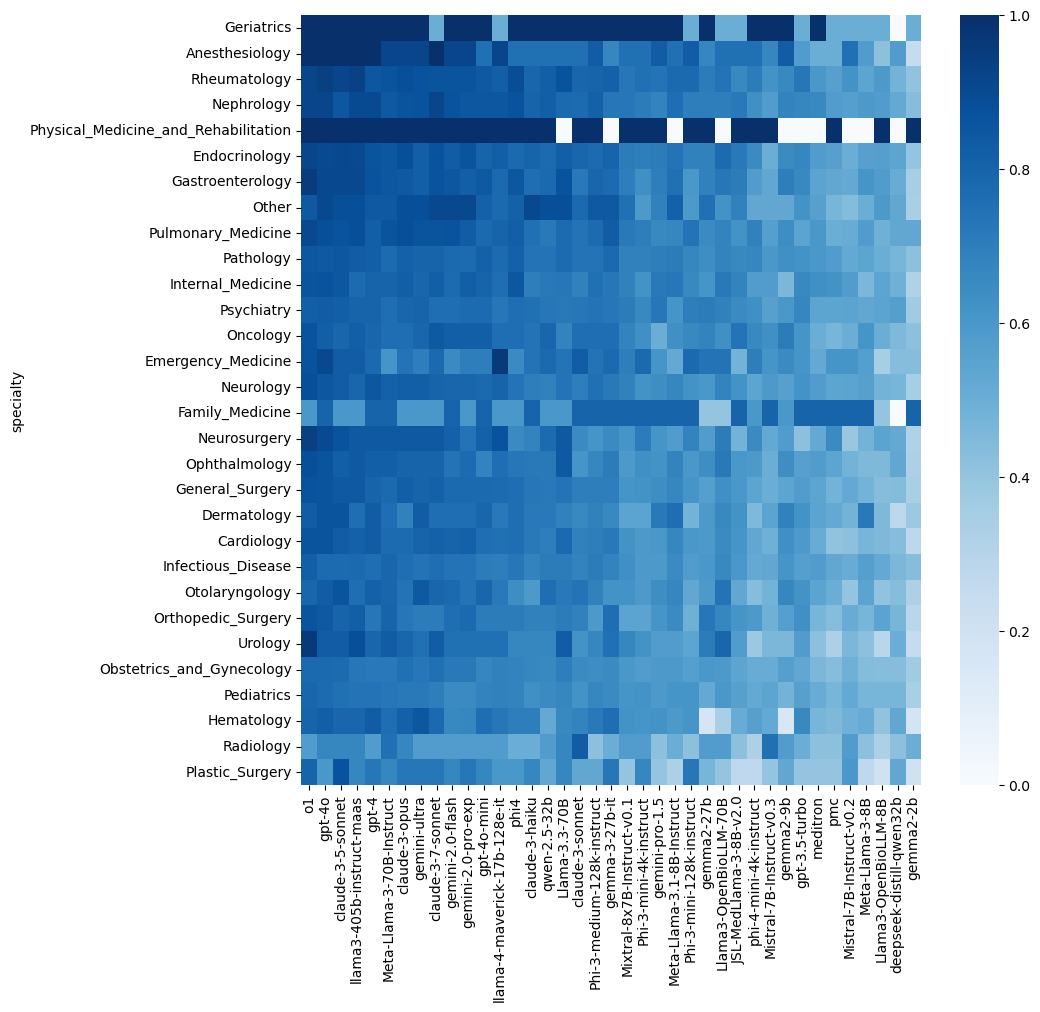

In [253]:
plt.figure(figsize=(10,10))
plt.xlabel('models')
sns.heatmap(specs_df3,cmap='Blues')
plt.show()

In [2]:
r1 = pd.read_csv("deepseek-R1_3910.csv")
medgem1 = pd.read_csv("medgemma-4b-it_3910.csv")
medgem2 = pd.read_csv("medgemma-27b-text-it_3910.csv")

In [3]:
medgem1['preds'].isnull().sum()

0

In [29]:
mo = [r1,medgem1,medgem2]
names = ['Deepseek-R1','MedGemma-4b-it','MedGemma-27b-text-it']

In [37]:
specs = df['specialty'].unique()
specs_new = pd.DataFrame(specs, columns=['specialty'])

for i in range(len(mo)):
    
    df2 = mo[i].copy()
    df2 = df2.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')
    df2.rename(columns={'correct_answer_x': "correct_answer", "specialty_x" : "specialty", "country_x" : "country", "selected_option" : "preds"},inplace=True)
    df2['correct'] = df2.apply(calculate_score,axis=1)
    sc = []
    for s in range(len(df2)):
        if df2['correct'][s] == True:
            x = 1
        else:
            x = 0
        sc.append(x)

    df2['score'] = sc
    avr = df2['score'].mean()
    print(f"{names[i]}:{avr}")
    d = df2.groupby('specialty').agg({'specialty':'count','score':'sum'})
    d['score'] = round(d['score']/d['specialty'],2)
    d.rename(columns={'score':names[i]},inplace=True)
    d.drop(columns=['specialty'],inplace=True)
    d.reset_index(inplace=True)
    specs_new = specs_new.merge(d,on='specialty',how='outer')
  

Deepseek-R1:0.7511508951406649
MedGemma-4b-it:0.5649616368286445
MedGemma-27b-text-it:0.541687979539642


In [36]:
specs_new

,specialty,Deepseek-R1,MedGemma-4b-it,MedGemma-27b-text-it
0,Allergy_and_Immunology,NaN,NaN,NaN
1,Anesthesiology,0.75,0.83,0.58
2,Cardiology,0.77,0.56,0.60
3,Communicable_Disease,NaN,NaN,NaN
4,Dermatology,0.76,0.59,0.52
5,Emergency_Medicine,0.87,0.65,0.48
6,Endocrinology,0.87,0.69,0.58
7,Family_Medicine,0.60,0.80,0.60
8,Gastroenterology,0.88,0.59,0.57
9,General,NaN,NaN,NaN


In [44]:
o3 = pd.read_csv("/home/chinemelu/AfriMed-QA/afri_results/o3_0.8422_3910.csv")

In [45]:
o3 = o3.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')

In [46]:
o3['correct'] = o3.apply(calculate_score,axis=1)

In [47]:
sc = []
for i in range(len(o3)):
    if o3['correct'][i] == True:
        x = 1
    else:
        x = 0
    sc.append(x)

o3['score'] = sc

In [48]:
o3['correct'].mean()

0.8554987212276215

In [49]:
o3['score'].mean()

0.8554987212276215

In [50]:
gem25 = pd.read_csv("gemini-2.5-flash_0.7829_3910.csv")

In [51]:
gem25 = gem25.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')

In [52]:
gem25['correct'] = gem25.apply(calculate_score,axis=1)

In [53]:
gem25['correct'].mean()

0.8107416879795396

In [54]:
sc = []
for i in range(len(gem25)):
    if gem25['correct'][i] == True:
        x = 1
    else:
        x = 0
    sc.append(x)

gem25['score'] = sc

In [55]:
gem25.head()

,Unnamed: 0,sample_id,question,rationale,options_len,answer,A,B,C,D,E,model_prompt,outputs,preds,correct,specialty,country,correct_answer2,score
0,0,a7ee602bfd80746f73e7ce59d70ab8900b0d7ebe402410...,You are counseling the family of a 15-year-old...,A duodenal switch is a primarily malabsorptive...,4,D,Laparoscopic adjustable gastric banding (LAGB),Roux-en-Y gastric bypass (RYGB),laparoscopic sleeve gastrectomy (LSG),biliopancreatic diversion with duodenal switch...,NaN,###Instruction: The following are multiple cho...,D. biliopancreatic diversion with duodenal swi...,D,1,Pediatrics,ZA,D,1
1,1,06bcc20456d81d9d68cb646e92aba0a4718b0088899d09...,A 14-year-old male is being assessed for weigh...,Diabetes and obstructive sleep apnea are consi...,4,B,BMI 32 and Type II diabetes,BMI 37 and obstructive sleep apnea,BMI 37 and hypertension,BMI 46 and no identifiable co-morbidities,NaN,###Instruction: The following are multiple cho...,NaN,N,0,Pediatrics,ZA,B,0
2,2,2d6206ab0285667d016ba210e1aeaf3caed81db107fb32...,\r\n A 15-year-old female presents to a specia...,The terms overweight (BMI for age and gender ≥...,4,C,Obese,Normal,Overweight,Severely obese,NaN,###Instruction: The following are multiple cho...,C. Overweight\n\n**Rationale:**\n\nFor childre...,C,1,Pediatrics,ZA,C,1
3,3,85de0d8a61bbf0c8007362fc23c17cb4cd515bf75afe1a...,Following resection of a patent urachus and bl...,A patent urachus requires investigation of the...,4,D,"Discharge when well with catheter in situ, and...",Removal of catheter 24 to 48 hours post op and...,Inpatient ultrasound and discharge if normal,Voiding cystourethrogram after removal of cath...,NaN,###Instruction: The following are multiple cho...,**Answer:** A\n\n**Rationale:**\nFollowing res...,A,0,Pediatrics,ZA,D,0
4,4,7482c32ae9a860247b3449a230e5eee576e5284cd9a57f...,A 1-week old term baby presents with clear flu...,Failure to adequately resect the patent urachu...,4,D,Suture ligate the patent urachus at the umbilicus,Ligate and divide the patent urachus at the do...,Resect the entire patent urachus and ligate an...,"Excision of the patent urachus, with wedge res...",NaN,###Instruction: The following are multiple cho...,"**D. Excision of the patent urachus, with wedg...",D,1,Pediatrics,ZA,D,1


In [56]:
g = gem25.groupby('specialty').agg({'specialty':'count','score':'sum'})
g['score'] = round(g['score']/g['specialty'],2)
g

,specialty,score
specialty,,
Anesthesiology,12,0.92
Cardiology,172,0.85
Dermatology,29,0.79
Emergency_Medicine,23,0.83
Endocrinology,137,0.93
Family_Medicine,5,0.80
Gastroenterology,130,0.93
General_Surgery,488,0.82
Geriatrics,2,1.00


In [57]:
o = o3.groupby('specialty').agg({'specialty':'count','score':'sum'})
o['score'] = round(o['score']/o['specialty'],2)
o

,specialty,score
specialty,,
Anesthesiology,12,1.00
Cardiology,172,0.87
Dermatology,29,0.90
Emergency_Medicine,23,0.96
Endocrinology,137,0.95
Family_Medicine,5,0.60
Gastroenterology,130,0.96
General_Surgery,488,0.88
Geriatrics,2,1.00


In [58]:
mo = [o3,gem25]
names = ['OpenAI-03','gemini-2.5-flash']

In [62]:
specs = df['specialty'].unique()
specs_new = pd.DataFrame(specs, columns=['specialty'])

for i in range(len(mo)):
    
    df2 = mo[i].copy()
    df2.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')
    df2['correct'] = df2.apply(calculate_score,axis=1)
    sc = []
    for s in range(len(df2)):
        if df2['correct'][s] == True:
            x = 1
        else:
            x = 0
        sc.append(x)

    df2['score'] = sc
    avr = df2['score'].mean()
    d = df2.groupby('specialty').agg({'specialty':'count','score':'sum'})
    d['score'] = round(d['score']/d['specialty'],2)
    d.rename(columns={'score':names[i]},inplace=True)
    d.drop(columns=['specialty'],inplace=True)
    d.reset_index(inplace=True)
    specs_new = specs_new.merge(d,on='specialty',how='outer')
  
    

In [63]:
specs_new

,specialty,OpenAI-03,gemini-2.5-flash
0,Allergy_and_Immunology,NaN,NaN
1,Anesthesiology,1.00,0.92
2,Cardiology,0.87,0.85
3,Communicable_Disease,NaN,NaN
4,Dermatology,0.90,0.79
5,Emergency_Medicine,0.96,0.83
6,Endocrinology,0.95,0.93
7,Family_Medicine,0.60,0.80
8,Gastroenterology,0.96,0.93
9,General,NaN,NaN


In [67]:
specs_new

,specialty,OpenAI-03,gemini-2.5-flash
0,Allergy_and_Immunology,NaN,NaN
1,Anesthesiology,1.00,0.92
2,Cardiology,0.87,0.85
3,Communicable_Disease,NaN,NaN
4,Dermatology,0.90,0.79
5,Emergency_Medicine,0.96,0.83
6,Endocrinology,0.95,0.93
7,Family_Medicine,0.60,0.80
8,Gastroenterology,0.96,0.93
9,General,NaN,NaN


In [38]:
specs3 = pd.read_csv('/home/chinemelu/AfriMed-QA/afri_results/specs_w_o3.csv')
specs3.rename(columns={'Specialty':'specialty'},inplace=True)
specs3.head(3)

,specialty,Domain,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,phi-4-mini-4k-instruct,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
0,Rheumatology,Medicine,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.71,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41
1,Nephrology,Medicine,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.87,0.85,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.63,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43
2,Endocrinology,Medicine,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.83,0.86,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.65,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40


In [39]:
spec3_n = specs3.merge(specs_new,on='specialty', how='left')
spec3_n

,specialty,Domain,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,phi-4-mini-4k-instruct,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b,Deepseek-R1,MedGemma-4b-it,MedGemma-27b-text-it
0,Rheumatology,Medicine,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.71,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41,0.84,0.69,0.66
1,Nephrology,Medicine,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.87,0.85,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.63,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43,0.80,0.70,0.58
2,Endocrinology,Medicine,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.83,0.86,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.65,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40,0.87,0.69,0.58
3,Gastroenterology,Medicine,0.96,0.95,0.91,0.91,0.93,0.91,0.87,0.87,0.82,0.84,0.85,0.85,0.82,0.84,0.78,0.87,0.85,0.77,0.78,0.76,0.79,0.72,0.73,0.75,0.70,0.70,0.63,0.60,0.69,0.71,0.66,0.70,0.58,0.55,0.53,0.61,0.53,0.52,0.58,0.51,0.35,0.88,0.59,0.57
4,Other,Medicine,0.88,0.84,0.91,0.88,0.81,0.88,0.84,0.91,0.88,0.88,0.84,0.91,0.91,0.81,0.78,0.88,0.81,0.84,0.88,0.91,0.84,0.78,0.62,0.81,0.75,0.69,0.59,0.59,0.75,0.69,0.62,0.53,0.53,0.56,0.53,0.50,0.47,0.44,0.59,0.53,0.34,0.91,0.56,0.62
5,Pulmonary_Medicine,Medicine,0.94,0.91,0.88,0.87,0.91,0.88,0.82,0.86,0.86,0.88,0.86,0.87,0.83,0.78,0.80,0.77,0.82,0.83,0.72,0.75,0.77,0.74,0.68,0.67,0.72,0.66,0.70,0.74,0.65,0.62,0.55,0.64,0.69,0.60,0.57,0.58,0.50,0.51,0.49,0.53,0.53,0.85,0.66,0.63
6,Pathology,Pathology,0.89,0.85,0.84,0.85,0.82,0.83,0.82,0.80,0.80,0.81,0.77,0.78,0.77,0.81,0.77,0.77,0.81,0.78,0.74,0.74,0.74,0.74,0.68,0.71,0.69,0.70,0.69,0.67,0.64,0.66,0.62,0.63,0.67,0.60,0.60,0.54,0.58,0.52,0.50,0.47,0.42,0.76,0.62,0.62
7,Internal_Medicine,Medicine,0.87,0.86,0.87,0.85,0.82,0.77,0.80,0.82,0.79,0.82,0.80,0.77,0.82,0.80,0.76,0.73,0.85,0.73,0.72,0.70,0.75,0.69,0.72,0.73,0.69,0.72,0.62,0.66,0.61,0.68,0.66,0.46,0.58,0.63,0.58,0.46,0.62,0.58,0.54,0.49,0.32,0.73,0.65,0.59
8,Oncology,Surgery,0.87,0.87,0.82,0.79,0.84,0.82,0.79,0.84,0.79,0.76,0.76,0.82,0.82,0.82,0.76,0.68,0.76,0.76,0.79,0.74,0.76,0.76,0.63,0.63,0.68,0.50,0.63,0.66,0.68,0.74,0.61,0.71,0.66,0.50,0.63,0.61,0.47,0.50,0.50,0.45,0.42,0.76,0.53,0.53
9,Psychiatry,Medicine,0.82,0.82,0.83,0.82,0.82,0.80,0.80,0.76,0.80,0.79,0.76,0.76,0.77,0.77,0.73,0.72,0.76,0.73,0.73,0.75,0.74,0.73,0.69,0.61,0.71,0.73,0.66,0.70,0.71,0.65,0.67,0.60,0.63,0.54,0.56,0.53,0.54,0.55,0.55,0.57,0.37,0.76,0.57,0.59


In [40]:
spec_d = spec3_n[['specialty','Domain']]
spec3_n.drop('Domain',axis=1,inplace=True)

In [41]:
spec3_n

,specialty,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,phi-4-mini-4k-instruct,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b,Deepseek-R1,MedGemma-4b-it,MedGemma-27b-text-it
0,Rheumatology,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.71,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41,0.84,0.69,0.66
1,Nephrology,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.87,0.85,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.63,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43,0.80,0.70,0.58
2,Endocrinology,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.83,0.86,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.65,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40,0.87,0.69,0.58
3,Gastroenterology,0.96,0.95,0.91,0.91,0.93,0.91,0.87,0.87,0.82,0.84,0.85,0.85,0.82,0.84,0.78,0.87,0.85,0.77,0.78,0.76,0.79,0.72,0.73,0.75,0.70,0.70,0.63,0.60,0.69,0.71,0.66,0.70,0.58,0.55,0.53,0.61,0.53,0.52,0.58,0.51,0.35,0.88,0.59,0.57
4,Other,0.88,0.84,0.91,0.88,0.81,0.88,0.84,0.91,0.88,0.88,0.84,0.91,0.91,0.81,0.78,0.88,0.81,0.84,0.88,0.91,0.84,0.78,0.62,0.81,0.75,0.69,0.59,0.59,0.75,0.69,0.62,0.53,0.53,0.56,0.53,0.50,0.47,0.44,0.59,0.53,0.34,0.91,0.56,0.62
5,Pulmonary_Medicine,0.94,0.91,0.88,0.87,0.91,0.88,0.82,0.86,0.86,0.88,0.86,0.87,0.83,0.78,0.80,0.77,0.82,0.83,0.72,0.75,0.77,0.74,0.68,0.67,0.72,0.66,0.70,0.74,0.65,0.62,0.55,0.64,0.69,0.60,0.57,0.58,0.50,0.51,0.49,0.53,0.53,0.85,0.66,0.63
6,Pathology,0.89,0.85,0.84,0.85,0.82,0.83,0.82,0.80,0.80,0.81,0.77,0.78,0.77,0.81,0.77,0.77,0.81,0.78,0.74,0.74,0.74,0.74,0.68,0.71,0.69,0.70,0.69,0.67,0.64,0.66,0.62,0.63,0.67,0.60,0.60,0.54,0.58,0.52,0.50,0.47,0.42,0.76,0.62,0.62
7,Internal_Medicine,0.87,0.86,0.87,0.85,0.82,0.77,0.80,0.82,0.79,0.82,0.80,0.77,0.82,0.80,0.76,0.73,0.85,0.73,0.72,0.70,0.75,0.69,0.72,0.73,0.69,0.72,0.62,0.66,0.61,0.68,0.66,0.46,0.58,0.63,0.58,0.46,0.62,0.58,0.54,0.49,0.32,0.73,0.65,0.59
8,Oncology,0.87,0.87,0.82,0.79,0.84,0.82,0.79,0.84,0.79,0.76,0.76,0.82,0.82,0.82,0.76,0.68,0.76,0.76,0.79,0.74,0.76,0.76,0.63,0.63,0.68,0.50,0.63,0.66,0.68,0.74,0.61,0.71,0.66,0.50,0.63,0.61,0.47,0.50,0.50,0.45,0.42,0.76,0.53,0.53
9,Psychiatry,0.82,0.82,0.83,0.82,0.82,0.80,0.80,0.76,0.80,0.79,0.76,0.76,0.77,0.77,0.73,0.72,0.76,0.73,0.73,0.75,0.74,0.73,0.69,0.61,0.71,0.73,0.66,0.70,0.71,0.65,0.67,0.60,0.63,0.54,0.56,0.53,0.54,0.55,0.55,0.57,0.37,0.76,0.57,0.59


In [42]:
spec3_n.sum().to_frame().drop('specialty').sort_values(by=0,ascending=False).index


Index(['OpenAI-03', 'OpenAI-o1', 'gpt-4o', 'claude-3-5-sonnet',
       'gemini-2.5-flash', 'llama3-405b-instruct-maas', 'gpt-4',
       'claude-3-7-sonnet', 'gemini-ultra', 'claude-3-opus',
       'Meta-Llama-3-70B-Instruct', 'Deepseek-R1', 'gemini-2.0-pro-exp',
       'gemini-2.0-flash', 'gpt-4o-mini', 'llama-4-maverick-17b-128e-it',
       'Llama-3.3-70B', 'phi4', 'gemma-3-27b-it', 'qwen-2.5-32b',
       'claude-3-haiku', 'Phi-3-medium-128k-instruct', 'claude-3-sonnet',
       'Llama3-OpenBioLLM-70B', 'Meta-Llama-3.1-8B-Instruct',
       'Mixtral-8x7B-Instruct-v0.1', 'gemini-pro-1.5',
       'Phi-3-mini-4k-instruct', 'Phi-3-mini-128k-instruct', 'gemma2-27b',
       'JSL-MedLlama-3-8B-v2.0', 'gpt-3.5-turbo', 'gemma2-9b',
       'MedGemma-4b-it', 'phi-4-mini-4k-instruct', 'MedGemma-27b-text-it',
       'meditron-7b', 'Mistral-7B-Instruct-v0.3', 'Meta-Llama-3-8B',
       'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2', 'Llama3-OpenBioLLM-8B',
       'deepseek-distill-qwen32b', 'gemma2-2b'

In [43]:
cols = ['specialty','OpenAI-03', 'OpenAI-o1', 'gpt-4o', 'claude-3-5-sonnet',
       'gemini-2.5-flash', 'llama3-405b-instruct-maas', 'gpt-4',
       'claude-3-7-sonnet', 'gemini-ultra', 'claude-3-opus',
       'Meta-Llama-3-70B-Instruct', 'Deepseek-R1', 'gemini-2.0-pro-exp',
       'gemini-2.0-flash', 'gpt-4o-mini', 'llama-4-maverick-17b-128e-it',
       'Llama-3.3-70B', 'phi4', 'gemma-3-27b-it', 'qwen-2.5-32b',
       'claude-3-haiku', 'Phi-3-medium-128k-instruct', 'claude-3-sonnet',
       'Llama3-OpenBioLLM-70B', 'Meta-Llama-3.1-8B-Instruct',
       'Mixtral-8x7B-Instruct-v0.1', 'gemini-pro-1.5',
       'Phi-3-mini-4k-instruct', 'Phi-3-mini-128k-instruct', 'gemma2-27b',
       'JSL-MedLlama-3-8B-v2.0', 'gpt-3.5-turbo', 'gemma2-9b',
       'MedGemma-4b-it', 'phi-4-mini-4k-instruct', 'MedGemma-27b-text-it',
       'meditron-7b', 'Mistral-7B-Instruct-v0.3', 'Meta-Llama-3-8B',
       'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2', 'Llama3-OpenBioLLM-8B',
       'deepseek-distill-qwen32b', 'gemma2-2b']

In [44]:
spec3_n = spec3_n[cols]

In [45]:
spec3_n = spec3_n.set_index('specialty')
spec3_n['sum']= spec3_n.sum(axis=1)
specs_df3 = spec3_n.sort_values(by='sum', ascending=False).drop('sum', axis=1)

In [46]:
specs_df3.reset_index(inplace=True)
specs_df3

,specialty,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,Deepseek-R1,gemini-2.0-pro-exp,gemini-2.0-flash,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,MedGemma-4b-it,phi-4-mini-4k-instruct,MedGemma-27b-text-it,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
0,Rheumatology,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.84,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.69,0.71,0.66,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41
1,Nephrology,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.80,0.85,0.87,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.70,0.63,0.58,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43
2,Endocrinology,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.87,0.86,0.83,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.69,0.65,0.58,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40
3,Gastroenterology,0.96,0.95,0.91,0.91,0.93,0.91,0.87,0.87,0.82,0.84,0.85,0.88,0.82,0.85,0.84,0.78,0.87,0.85,0.77,0.78,0.76,0.79,0.72,0.73,0.75,0.70,0.70,0.63,0.60,0.69,0.71,0.66,0.70,0.59,0.58,0.57,0.55,0.53,0.61,0.53,0.52,0.58,0.51,0.35
4,Other,0.88,0.84,0.91,0.88,0.81,0.88,0.84,0.91,0.88,0.88,0.84,0.91,0.91,0.91,0.81,0.78,0.88,0.81,0.84,0.88,0.91,0.84,0.78,0.62,0.81,0.75,0.69,0.59,0.59,0.75,0.69,0.62,0.53,0.56,0.53,0.62,0.56,0.53,0.50,0.47,0.44,0.59,0.53,0.34
5,Pulmonary_Medicine,0.94,0.91,0.88,0.87,0.91,0.88,0.82,0.86,0.86,0.88,0.86,0.85,0.83,0.87,0.78,0.80,0.77,0.82,0.83,0.72,0.75,0.77,0.74,0.68,0.67,0.72,0.66,0.70,0.74,0.65,0.62,0.55,0.64,0.66,0.69,0.63,0.60,0.57,0.58,0.50,0.51,0.49,0.53,0.53
6,Pathology,0.89,0.85,0.84,0.85,0.82,0.83,0.82,0.80,0.80,0.81,0.77,0.76,0.77,0.78,0.81,0.77,0.77,0.81,0.78,0.74,0.74,0.74,0.74,0.68,0.71,0.69,0.70,0.69,0.67,0.64,0.66,0.62,0.63,0.62,0.67,0.62,0.60,0.60,0.54,0.58,0.52,0.50,0.47,0.42
7,Internal_Medicine,0.87,0.86,0.87,0.85,0.82,0.77,0.80,0.82,0.79,0.82,0.80,0.73,0.82,0.77,0.80,0.76,0.73,0.85,0.73,0.72,0.70,0.75,0.69,0.72,0.73,0.69,0.72,0.62,0.66,0.61,0.68,0.66,0.46,0.65,0.58,0.59,0.63,0.58,0.46,0.62,0.58,0.54,0.49,0.32
8,Emergency_Medicine,0.96,0.87,0.91,0.83,0.83,0.83,0.78,0.78,0.70,0.74,0.61,0.87,0.70,0.65,0.70,0.96,0.74,0.65,0.78,0.78,0.74,0.74,0.83,0.74,0.52,0.70,0.61,0.78,0.78,0.74,0.48,0.61,0.65,0.65,0.70,0.48,0.52,0.61,0.57,0.61,0.61,0.35,0.43,0.43
9,Psychiatry,0.82,0.82,0.83,0.82,0.82,0.80,0.80,0.76,0.80,0.79,0.76,0.76,0.77,0.76,0.77,0.73,0.72,0.76,0.73,0.73,0.75,0.74,0.73,0.69,0.61,0.71,0.73,0.66,0.70,0.71,0.65,0.67,0.60,0.57,0.63,0.59,0.54,0.56,0.53,0.54,0.55,0.55,0.57,0.37


In [48]:
cols = ['specialty', 'Domain', 'OpenAI-03', 'OpenAI-o1', 'gpt-4o', 'claude-3-5-sonnet',
       'gemini-2.5-flash', 'llama3-405b-instruct-maas', 'gpt-4',
       'claude-3-7-sonnet', 'gemini-ultra', 'claude-3-opus',
       'Meta-Llama-3-70B-Instruct', 'Deepseek-R1', 'gemini-2.0-pro-exp',
       'gemini-2.0-flash', 'gpt-4o-mini', 'llama-4-maverick-17b-128e-it',
       'Llama-3.3-70B', 'phi4', 'gemma-3-27b-it', 'qwen-2.5-32b',
       'claude-3-haiku', 'Phi-3-medium-128k-instruct', 'claude-3-sonnet',
       'Llama3-OpenBioLLM-70B', 'Meta-Llama-3.1-8B-Instruct',
       'Mixtral-8x7B-Instruct-v0.1', 'gemini-pro-1.5',
       'Phi-3-mini-4k-instruct', 'Phi-3-mini-128k-instruct', 'gemma2-27b',
       'JSL-MedLlama-3-8B-v2.0', 'gpt-3.5-turbo', 'gemma2-9b',
       'MedGemma-4b-it', 'phi-4-mini-4k-instruct', 'MedGemma-27b-text-it',
       'meditron-7b', 'Mistral-7B-Instruct-v0.3', 'Meta-Llama-3-8B',
       'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2', 'Llama3-OpenBioLLM-8B',
       'deepseek-distill-qwen32b', 'gemma2-2b']

In [47]:
specs_df4 = specs_df3.merge(spec_d, on='specialty',how='inner')
specs_df4

,specialty,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,Deepseek-R1,gemini-2.0-pro-exp,gemini-2.0-flash,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,MedGemma-4b-it,phi-4-mini-4k-instruct,MedGemma-27b-text-it,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b,Domain
0,Rheumatology,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.84,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.69,0.71,0.66,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41,Medicine
1,Nephrology,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.80,0.85,0.87,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.70,0.63,0.58,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43,Medicine
2,Endocrinology,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.87,0.86,0.83,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.69,0.65,0.58,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40,Medicine
3,Gastroenterology,0.96,0.95,0.91,0.91,0.93,0.91,0.87,0.87,0.82,0.84,0.85,0.88,0.82,0.85,0.84,0.78,0.87,0.85,0.77,0.78,0.76,0.79,0.72,0.73,0.75,0.70,0.70,0.63,0.60,0.69,0.71,0.66,0.70,0.59,0.58,0.57,0.55,0.53,0.61,0.53,0.52,0.58,0.51,0.35,Medicine
4,Other,0.88,0.84,0.91,0.88,0.81,0.88,0.84,0.91,0.88,0.88,0.84,0.91,0.91,0.91,0.81,0.78,0.88,0.81,0.84,0.88,0.91,0.84,0.78,0.62,0.81,0.75,0.69,0.59,0.59,0.75,0.69,0.62,0.53,0.56,0.53,0.62,0.56,0.53,0.50,0.47,0.44,0.59,0.53,0.34,Medicine
5,Pulmonary_Medicine,0.94,0.91,0.88,0.87,0.91,0.88,0.82,0.86,0.86,0.88,0.86,0.85,0.83,0.87,0.78,0.80,0.77,0.82,0.83,0.72,0.75,0.77,0.74,0.68,0.67,0.72,0.66,0.70,0.74,0.65,0.62,0.55,0.64,0.66,0.69,0.63,0.60,0.57,0.58,0.50,0.51,0.49,0.53,0.53,Medicine
6,Pathology,0.89,0.85,0.84,0.85,0.82,0.83,0.82,0.80,0.80,0.81,0.77,0.76,0.77,0.78,0.81,0.77,0.77,0.81,0.78,0.74,0.74,0.74,0.74,0.68,0.71,0.69,0.70,0.69,0.67,0.64,0.66,0.62,0.63,0.62,0.67,0.62,0.60,0.60,0.54,0.58,0.52,0.50,0.47,0.42,Pathology
7,Internal_Medicine,0.87,0.86,0.87,0.85,0.82,0.77,0.80,0.82,0.79,0.82,0.80,0.73,0.82,0.77,0.80,0.76,0.73,0.85,0.73,0.72,0.70,0.75,0.69,0.72,0.73,0.69,0.72,0.62,0.66,0.61,0.68,0.66,0.46,0.65,0.58,0.59,0.63,0.58,0.46,0.62,0.58,0.54,0.49,0.32,Medicine
8,Emergency_Medicine,0.96,0.87,0.91,0.83,0.83,0.83,0.78,0.78,0.70,0.74,0.61,0.87,0.70,0.65,0.70,0.96,0.74,0.65,0.78,0.78,0.74,0.74,0.83,0.74,0.52,0.70,0.61,0.78,0.78,0.74,0.48,0.61,0.65,0.65,0.70,0.48,0.52,0.61,0.57,0.61,0.61,0.35,0.43,0.43,Medicine
9,Psychiatry,0.82,0.82,0.83,0.82,0.82,0.80,0.80,0.76,0.80,0.79,0.76,0.76,0.77,0.76,0.77,0.73,0.72,0.76,0.73,0.73,0.75,0.74,0.73,0.69,0.61,0.71,0.73,0.66,0.70,0.71,0.65,0.67,0.60,0.57,0.63,0.59,0.54,0.56,0.53,0.54,0.55,0.55,0.57,0.37,Medicine


In [49]:
specs_df4 = specs_df4[cols]

In [90]:
specs_df4.rename(columns={'o1':'OpenAI-o1','meditron':'meditron-7b'}, inplace=True)

In [50]:
specs_df4

,specialty,Domain,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,Deepseek-R1,gemini-2.0-pro-exp,gemini-2.0-flash,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,MedGemma-4b-it,phi-4-mini-4k-instruct,MedGemma-27b-text-it,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
0,Rheumatology,Medicine,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.84,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.69,0.71,0.66,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41
1,Nephrology,Medicine,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.80,0.85,0.87,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.70,0.63,0.58,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43
2,Endocrinology,Medicine,0.95,0.92,0.90,0.91,0.93,0.90,0.86,0.87,0.82,0.88,0.85,0.87,0.86,0.83,0.80,0.82,0.82,0.78,0.80,0.77,0.80,0.77,0.79,0.77,0.74,0.71,0.71,0.70,0.69,0.69,0.72,0.67,0.65,0.69,0.65,0.58,0.58,0.50,0.56,0.56,0.50,0.57,0.54,0.40
3,Gastroenterology,Medicine,0.96,0.95,0.91,0.91,0.93,0.91,0.87,0.87,0.82,0.84,0.85,0.88,0.82,0.85,0.84,0.78,0.87,0.85,0.77,0.78,0.76,0.79,0.72,0.73,0.75,0.70,0.70,0.63,0.60,0.69,0.71,0.66,0.70,0.59,0.58,0.57,0.55,0.53,0.61,0.53,0.52,0.58,0.51,0.35
4,Other,Medicine,0.88,0.84,0.91,0.88,0.81,0.88,0.84,0.91,0.88,0.88,0.84,0.91,0.91,0.91,0.81,0.78,0.88,0.81,0.84,0.88,0.91,0.84,0.78,0.62,0.81,0.75,0.69,0.59,0.59,0.75,0.69,0.62,0.53,0.56,0.53,0.62,0.56,0.53,0.50,0.47,0.44,0.59,0.53,0.34
5,Pulmonary_Medicine,Medicine,0.94,0.91,0.88,0.87,0.91,0.88,0.82,0.86,0.86,0.88,0.86,0.85,0.83,0.87,0.78,0.80,0.77,0.82,0.83,0.72,0.75,0.77,0.74,0.68,0.67,0.72,0.66,0.70,0.74,0.65,0.62,0.55,0.64,0.66,0.69,0.63,0.60,0.57,0.58,0.50,0.51,0.49,0.53,0.53
6,Pathology,Pathology,0.89,0.85,0.84,0.85,0.82,0.83,0.82,0.80,0.80,0.81,0.77,0.76,0.77,0.78,0.81,0.77,0.77,0.81,0.78,0.74,0.74,0.74,0.74,0.68,0.71,0.69,0.70,0.69,0.67,0.64,0.66,0.62,0.63,0.62,0.67,0.62,0.60,0.60,0.54,0.58,0.52,0.50,0.47,0.42
7,Internal_Medicine,Medicine,0.87,0.86,0.87,0.85,0.82,0.77,0.80,0.82,0.79,0.82,0.80,0.73,0.82,0.77,0.80,0.76,0.73,0.85,0.73,0.72,0.70,0.75,0.69,0.72,0.73,0.69,0.72,0.62,0.66,0.61,0.68,0.66,0.46,0.65,0.58,0.59,0.63,0.58,0.46,0.62,0.58,0.54,0.49,0.32
8,Emergency_Medicine,Medicine,0.96,0.87,0.91,0.83,0.83,0.83,0.78,0.78,0.70,0.74,0.61,0.87,0.70,0.65,0.70,0.96,0.74,0.65,0.78,0.78,0.74,0.74,0.83,0.74,0.52,0.70,0.61,0.78,0.78,0.74,0.48,0.61,0.65,0.65,0.70,0.48,0.52,0.61,0.57,0.61,0.61,0.35,0.43,0.43
9,Psychiatry,Medicine,0.82,0.82,0.83,0.82,0.82,0.80,0.80,0.76,0.80,0.79,0.76,0.76,0.77,0.76,0.77,0.73,0.72,0.76,0.73,0.73,0.75,0.74,0.73,0.69,0.61,0.71,0.73,0.66,0.70,0.71,0.65,0.67,0.60,0.57,0.63,0.59,0.54,0.56,0.53,0.54,0.55,0.55,0.57,0.37


In [51]:
# Group by 'Domain' and calculate the mean for each model column (excluding 'specialty')
domain_means = specs_df4.groupby('Domain').mean(numeric_only=True)
domain_means

,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,Deepseek-R1,gemini-2.0-pro-exp,gemini-2.0-flash,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,MedGemma-4b-it,phi-4-mini-4k-instruct,MedGemma-27b-text-it,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
Domain,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Medicine,0.898462,0.876923,0.877692,0.856154,0.860000,0.841538,0.830000,0.829231,0.815385,0.816154,0.800000,0.813077,0.809231,0.804615,0.786923,0.790000,0.776923,0.790000,0.753846,0.756923,0.755385,0.758462,0.736154,0.695385,0.701538,0.686923,0.676154,0.653077,0.655385,0.663846,0.644615,0.633846,0.620,0.616154,0.595385,0.580000,0.573846,0.556923,0.558462,0.536154,0.527692,0.518462,0.480000,0.386154
Pathology,0.845000,0.825000,0.830000,0.820000,0.790000,0.810000,0.825000,0.790000,0.825000,0.810000,0.765000,0.720000,0.720000,0.720000,0.785000,0.750000,0.715000,0.755000,0.770000,0.630000,0.720000,0.730000,0.710000,0.510000,0.650000,0.655000,0.660000,0.650000,0.640000,0.405000,0.585000,0.640000,0.395,0.610000,0.615000,0.600000,0.535000,0.560000,0.525000,0.515000,0.505000,0.455000,0.500000,0.300000
Surgery,0.861111,0.860000,0.832222,0.814444,0.804444,0.807778,0.782222,0.785556,0.775556,0.772222,0.785556,0.750000,0.750000,0.756667,0.743333,0.746667,0.747778,0.697778,0.694444,0.714444,0.680000,0.666667,0.671111,0.675556,0.628889,0.615556,0.597778,0.616667,0.587778,0.624444,0.582222,0.565556,0.580,0.523333,0.541111,0.506667,0.505556,0.514444,0.485556,0.477778,0.474444,0.453333,0.471111,0.332222


In [52]:
domain_means.to_csv("avr_domain.csv")

In [53]:
specs_df4.to_csv('specs_w_R1.csv',index=False)

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

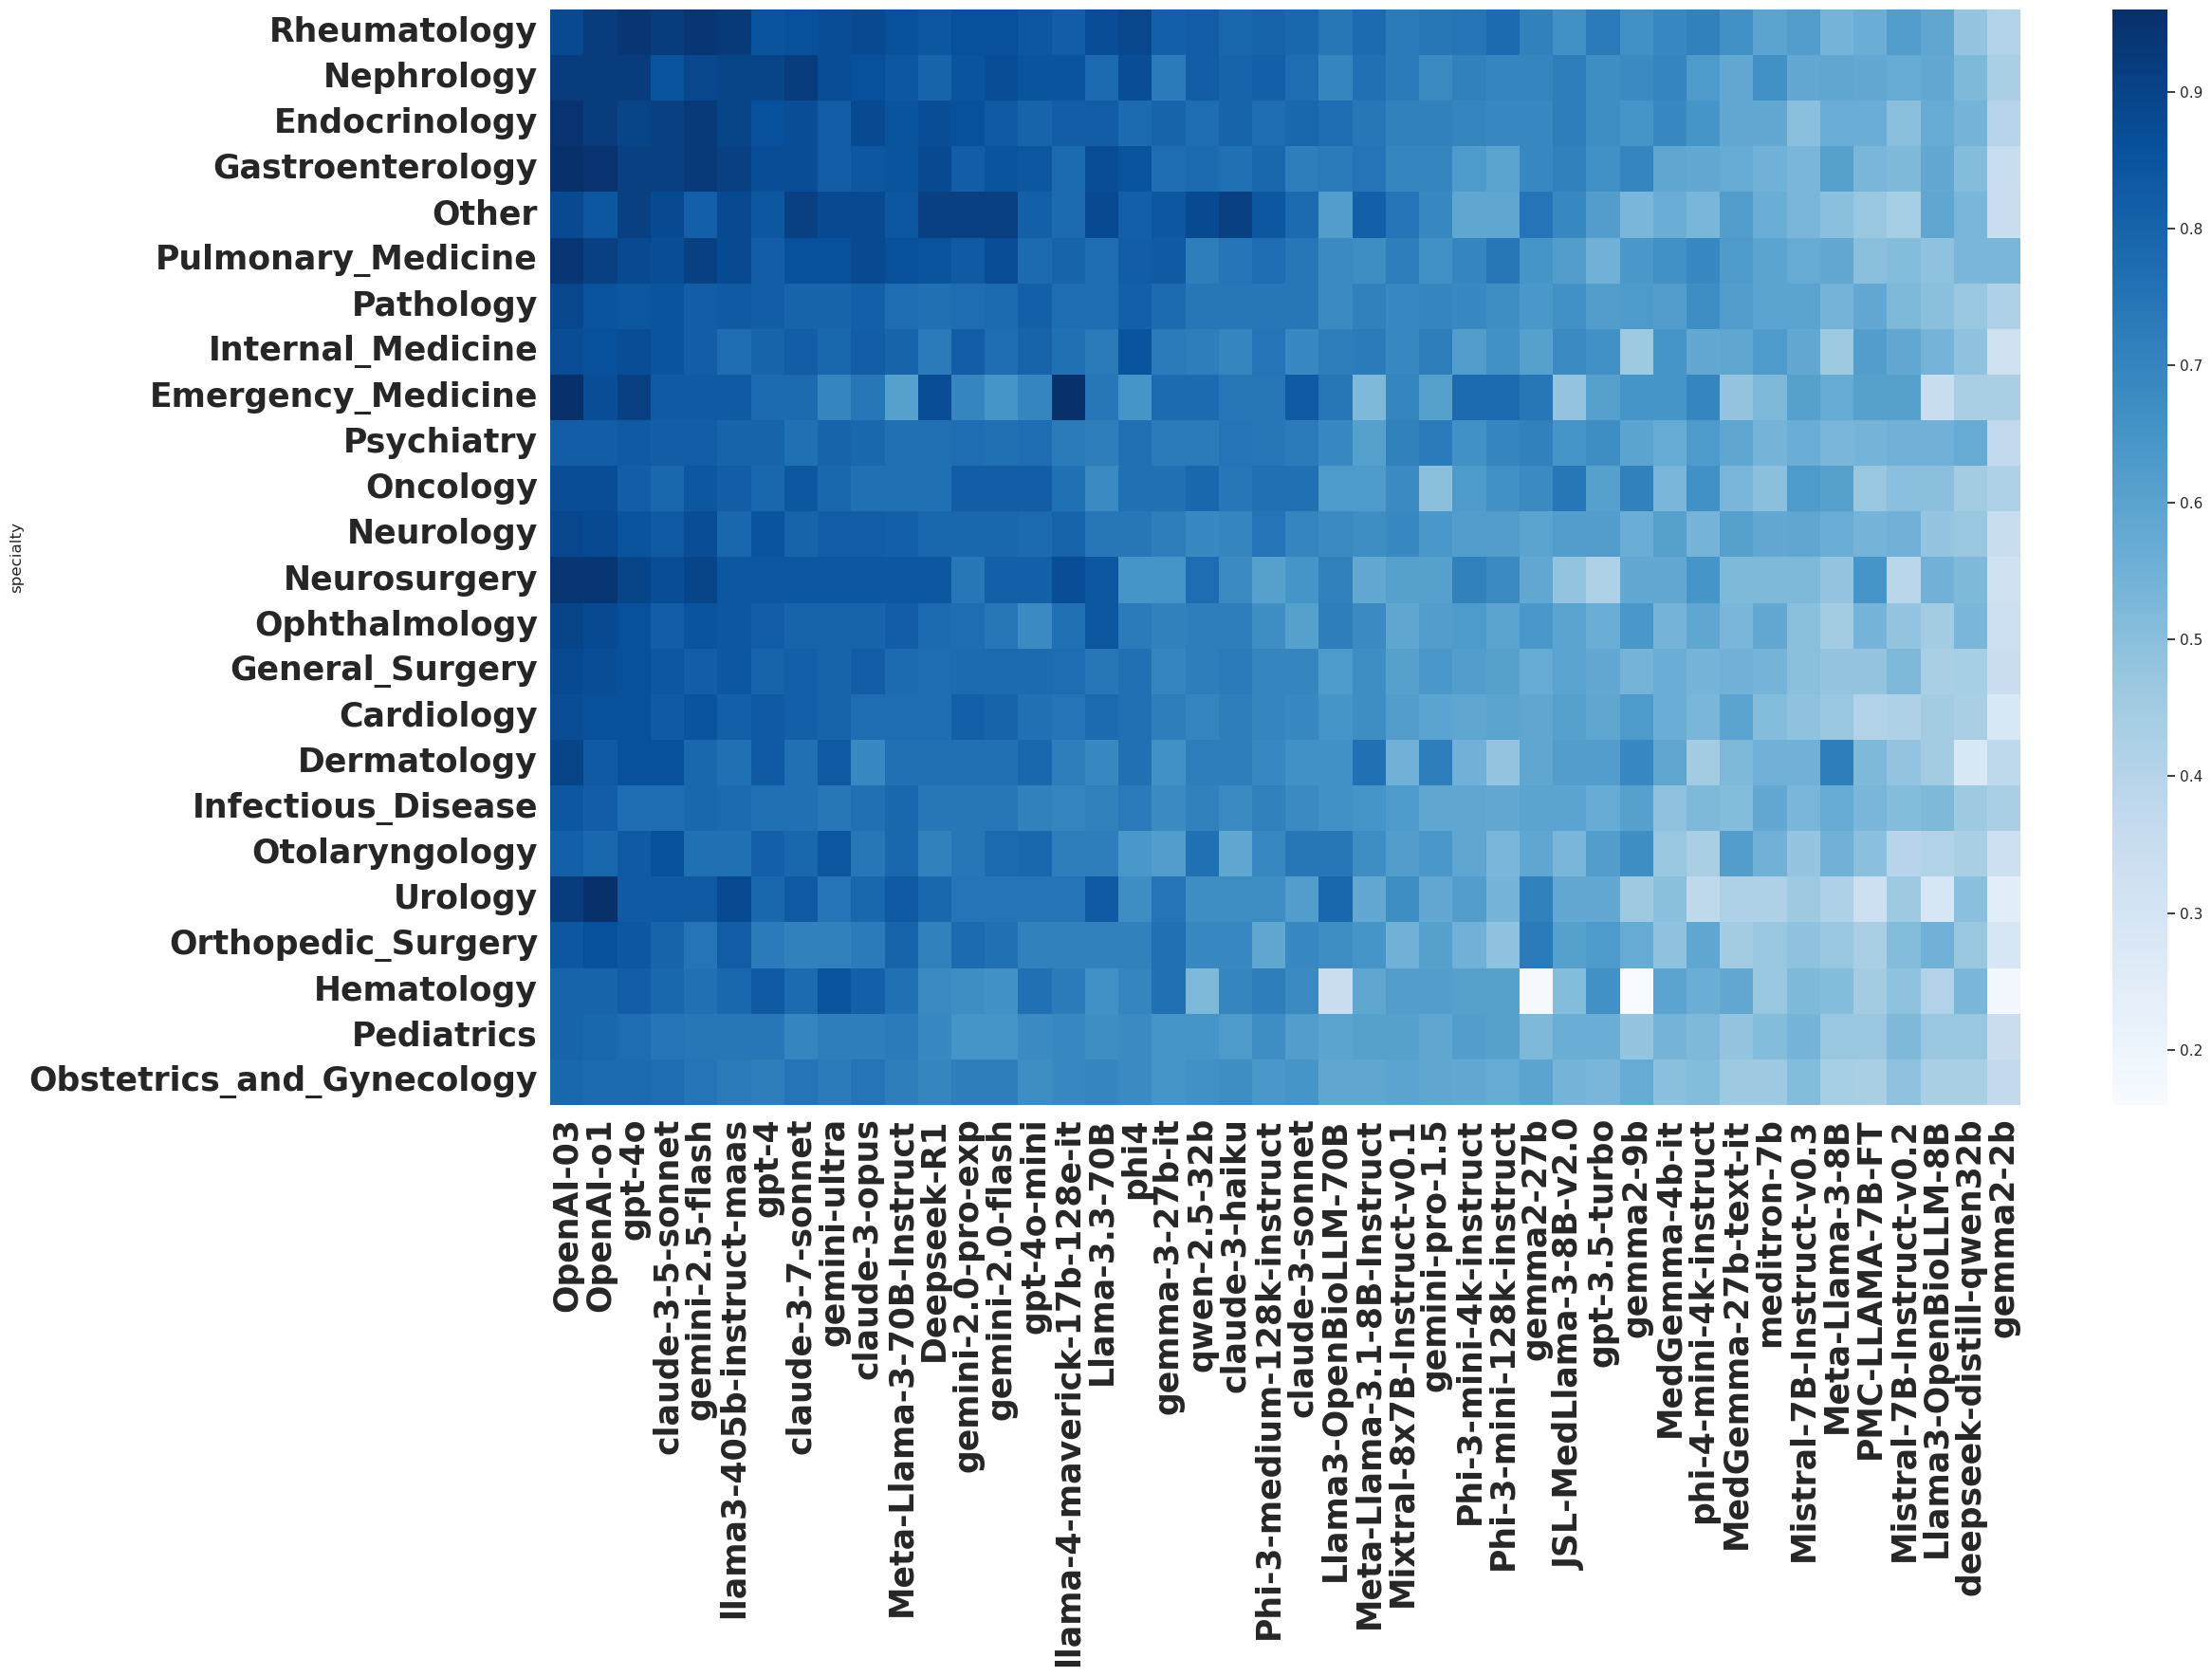

In [55]:
plt.figure(figsize=(25,15))
plt.xlabel('models')
sns.heatmap(specs_df4.drop(['Domain'],axis=1).set_index('specialty'),cmap='Blues')
plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.savefig("specialty_final.jpg", bbox_inches='tight')
plt.show()

## Base Instruct Fewshot

In [76]:
root_dir = "\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few"

bif = pd.DataFrame(columns=['model','score'])

models = []
scores = []
# Walk through each subdirectory in the root directory
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(subdir, file)
            # Read the CSV file and append it to the list
            df1 = pd.read_csv(file_path)
            df2 = processs_data2(df1)[2]
            avr = processs_data2(df1)[1]
            print(f"{file_path.split('\\')[-1].split('_')[0]}:{avr}")
            models.append(f"{file_path.split('\\')[-1].split('_')[0]}")
            scores.append(avr)
bif['model'] = models
bif['score'] = scores 

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipykernel_703522/743466798.py:1: SyntaxWarning: invalid escape sequence '\E'
  root_dir = "\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few"


In [78]:
gi = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gemma-3-27b-it/afrimed-qa-v2.5_gemma-3-27b-it_mcq_instruct-prompt__no_exp_0-shot_processed_score_0.6693_3910.csv")
gbf = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gemma-3-27b-it/afrimed-qa-v2.5_gemma-3-27b-it_mcq_base-prompt__no_exp_3-shot_processed_score_0.6723_3910.csv")
gif = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gemma-3-27b-it/afrimed-qa-v2.5_gemma-3-27b-it_mcq_instruct-prompt__no_exp_0-shot_processed_score_0.6693_3910.csv")
gb = pd.read_csv("/home/chinemelu/AfriMed-QA/results/gemma-3-27b-it/afrimed-qa-v2.5_gemma-3-27b-it_mcq_base-prompt__no_exp_0-shot_score_0.6780_3910.csv")

mods = [gi,gbf,gif,gb]
names = ['gemma-instruct', 'gemma-base-few', 'gemma-instruct-few', 'gemma-base']

In [90]:
specs = df['specialty'].unique()
specs_new = pd.DataFrame(specs, columns=['specialty'])

bif = pd.DataFrame(columns=['model','score'])

models = []
scores = []
for i in range(len(mods)):
    
    df2 = mods[i].copy()
    df2=df2.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')

    df2['correct'] = df2.apply(calculate_score,axis=1)
    sc = []
    for s in range(len(df2)):
        if df2['correct'][s] == True:
            x = 1
        else:
            x = 0
        sc.append(x)

    df2['score'] = sc

    score = df2['score'].mean()
    models.append(names[i])
    scores.append(score)

bif['model'] = models
bif['score'] = scores     


In [91]:
bif

,model,score
0,gemma-instruct,0.702813
1,gemma-base-few,0.708440
2,gemma-instruct-few,0.702813
3,gemma-base,0.709207


In [307]:
gb = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few\Llama-3-70B-It-base-fewshot_score_0.7317_3910.csv")
gf = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few\Llama-3-70B-It-instruct-fewshot_score_0.7338_3910.csv")

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Ezinwanne\AppData\Local\Temp\ipykernel_27584\320139238.py:1: SyntaxWarning: invalid escape sequence '\E'
  gb = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few\Llama-3-70B-It-base-fewshot_score_0.7317_3910.csv")
C:\Users\Ezinwanne\AppData\Local\Temp\ipykernel_27584\320139238.py:2: SyntaxWarning: invalid escape sequence '\E'
  gf = pd.read_csv("\\Users\Ezinwanne\Documents\personal\intron\AfriMed\\2025\AfriMed-QA\\base_instruct_few\Llama-3-70B-It-instruct-fewshot_score_0.7338_3910.csv")


In [308]:
gb1 = gb.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')
gf1 = gf.merge(df[['sample_id', 'specialty', 'country','correct_answer2']], on='sample_id',how='left')

In [312]:
gb1['correct'].mean()

0.769309462915601

In [313]:
gf1['correct'].mean()

0.769309462915601

In [311]:
gb1['correct'] = gb1.apply(calculate_score,axis=1)
gf1['correct'] = gf1.apply(calculate_score,axis=1)

In [314]:
(gb1['correct'] == gf1['correct']).mean()

0.9289002557544757

In [ ]:
gg = pd.DataFrame({"gb":gb1['preds'],"gf":gf1['preds']})

In [338]:
gg['cor'] = gg['gb'] == gg['gf']
gg

,gb,gf,cor
0,D,D,True
1,D,D,True
2,C,C,True
3,B,B,True
4,C,C,True
...,...,...,...
3905,C,C,True
3906,C,C,True
3907,C,C,True
3908,C,C,True


In [339]:
gg[(gg['gb'] == 1) & (gg['gf'] == 0)]['cor'].value_counts()

Series([], Name: count, dtype: int64)

In [340]:
gg['cor'].value_counts()

cor
True     3491
False     419
Name: count, dtype: int64

In [106]:
ch = pd.read_csv("/home/chinemelu/AfriMed-QA/afri_results/specs_w_o3.csv")

In [107]:
ch.drop('specialty',axis=1,inplace=True)

In [108]:
ch.head(2)

,Domain,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,phi-4-mini-4k-instruct,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
0,Medicine,0.88,0.92,0.94,0.92,0.94,0.93,0.85,0.86,0.87,0.88,0.86,0.86,0.86,0.84,0.82,0.87,0.89,0.81,0.82,0.79,0.80,0.79,0.74,0.78,0.73,0.74,0.75,0.78,0.71,0.66,0.73,0.66,0.71,0.60,0.62,0.54,0.56,0.62,0.59,0.48,0.41
1,Medicine,0.92,0.92,0.92,0.85,0.89,0.90,0.90,0.92,0.87,0.86,0.84,0.87,0.85,0.85,0.85,0.78,0.87,0.73,0.82,0.80,0.81,0.77,0.70,0.76,0.73,0.68,0.71,0.70,0.70,0.72,0.67,0.68,0.63,0.66,0.58,0.59,0.58,0.57,0.58,0.52,0.43


In [109]:
grouped = ch.groupby("Domain").mean()



In [110]:
grouped

,OpenAI-03,OpenAI-o1,gpt-4o,claude-3-5-sonnet,gemini-2.5-flash,llama3-405b-instruct-maas,gpt-4,claude-3-7-sonnet,gemini-ultra,claude-3-opus,Meta-Llama-3-70B-Instruct,gemini-2.0-flash,gemini-2.0-pro-exp,gpt-4o-mini,llama-4-maverick-17b-128e-it,Llama-3.3-70B,phi4,gemma-3-27b-it,qwen-2.5-32b,claude-3-haiku,Phi-3-medium-128k-instruct,claude-3-sonnet,Llama3-OpenBioLLM-70B,Meta-Llama-3.1-8B-Instruct,Mixtral-8x7B-Instruct-v0.1,gemini-pro-1.5,Phi-3-mini-4k-instruct,Phi-3-mini-128k-instruct,gemma2-27b,JSL-MedLlama-3-8B-v2.0,gpt-3.5-turbo,gemma2-9b,phi-4-mini-4k-instruct,meditron-7b,Mistral-7B-Instruct-v0.3,Meta-Llama-3-8B,PMC-LLAMA-7B-FT,Mistral-7B-Instruct-v0.2,Llama3-OpenBioLLM-8B,deepseek-distill-qwen32b,gemma2-2b
Domain,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Medicine,0.898462,0.876923,0.877692,0.856154,0.860000,0.841538,0.830000,0.829231,0.815385,0.816154,0.800000,0.804615,0.809231,0.786923,0.790000,0.776923,0.790000,0.753846,0.756923,0.755385,0.758462,0.736154,0.695385,0.701538,0.686923,0.676154,0.653077,0.655385,0.663846,0.644615,0.633846,0.620,0.595385,0.573846,0.556923,0.558462,0.536154,0.527692,0.518462,0.480000,0.386154
Pathology,0.845000,0.825000,0.830000,0.820000,0.790000,0.810000,0.825000,0.790000,0.825000,0.810000,0.765000,0.720000,0.720000,0.785000,0.750000,0.715000,0.755000,0.770000,0.630000,0.720000,0.730000,0.710000,0.510000,0.650000,0.655000,0.660000,0.650000,0.640000,0.405000,0.585000,0.640000,0.395,0.615000,0.535000,0.560000,0.525000,0.515000,0.505000,0.455000,0.500000,0.300000
Surgery,0.861111,0.860000,0.832222,0.814444,0.804444,0.807778,0.782222,0.785556,0.775556,0.772222,0.785556,0.756667,0.750000,0.743333,0.746667,0.747778,0.697778,0.694444,0.714444,0.680000,0.666667,0.671111,0.675556,0.628889,0.615556,0.597778,0.616667,0.587778,0.624444,0.582222,0.565556,0.580,0.541111,0.505556,0.514444,0.485556,0.477778,0.474444,0.453333,0.471111,0.332222


In [350]:
grouped.to_csv("domain_group.csv")

In [111]:
ch.columns

Index(['Domain', 'OpenAI-03', 'OpenAI-o1', 'gpt-4o', 'claude-3-5-sonnet',
       'gemini-2.5-flash', 'llama3-405b-instruct-maas', 'gpt-4',
       'claude-3-7-sonnet', 'gemini-ultra', 'claude-3-opus',
       'Meta-Llama-3-70B-Instruct', 'gemini-2.0-flash', 'gemini-2.0-pro-exp',
       'gpt-4o-mini', 'llama-4-maverick-17b-128e-it', 'Llama-3.3-70B', 'phi4',
       'gemma-3-27b-it', 'qwen-2.5-32b', 'claude-3-haiku',
       'Phi-3-medium-128k-instruct', 'claude-3-sonnet',
       'Llama3-OpenBioLLM-70B', 'Meta-Llama-3.1-8B-Instruct',
       'Mixtral-8x7B-Instruct-v0.1', 'gemini-pro-1.5',
       'Phi-3-mini-4k-instruct', 'Phi-3-mini-128k-instruct', 'gemma2-27b',
       'JSL-MedLlama-3-8B-v2.0', 'gpt-3.5-turbo', 'gemma2-9b',
       'phi-4-mini-4k-instruct', 'meditron-7b', 'Mistral-7B-Instruct-v0.3',
       'Meta-Llama-3-8B', 'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2',
       'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b'],
      dtype='object')

In [112]:
cols2 = ['OpenAI-03', 'OpenAI-o1', 'gpt-4o',
       'claude-3-5-sonnet', 'gemini-2.5-flash', 'llama3-405b-instruct-maas',
       'gpt-4', 'claude-3-7-sonnet', 'gemini-ultra', 'claude-3-opus',
       'Meta-Llama-3-70B-Instruct', 'gemini-2.0-flash', 'gemini-2.0-pro-exp',
       'gpt-4o-mini', 'llama-4-maverick-17b-128e-it', 'Llama-3.3-70B', 'phi4',
       'gemma-3-27b-it', 'qwen-2.5-32b', 'claude-3-haiku',
       'Phi-3-medium-128k-instruct', 'claude-3-sonnet',
       'Llama3-OpenBioLLM-70B', 'Meta-Llama-3.1-8B-Instruct',
       'Mixtral-8x7B-Instruct-v0.1', 'gemini-pro-1.5',
       'Phi-3-mini-4k-instruct', 'Phi-3-mini-128k-instruct', 'gemma2-27b',
       'JSL-MedLlama-3-8B-v2.0', 'gpt-3.5-turbo', 'gemma2-9b',
       'phi-4-mini-4k-instruct', 'meditron-7b', 'Mistral-7B-Instruct-v0.3',
       'Meta-Llama-3-8B', 'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2',
       'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b']

In [113]:
import pandas as pd
from scipy.stats import ttest_ind

# Your DataFrame: ch
# Columns: 'Domain', 'o1', 'gpt-4o', 'claude-3-5-sonnet', 'llama3-405b-instruct-maas'

models = cols2
domains = ['Medicine', 'Surgery']
m=[]
s=[]
for model in models:
    #print(f"\n🔍 T-tests across domains for model: {model}")
    print(f"\n T-tests across domains for model: {model}")
    m.append(model)
    for i in range(len(domains)):
        for j in range(i+1, len(domains)):
            d1 = domains[i]
            d2 = domains[j]
            
            scores_d1 = ch[ch['Domain'] == d1][model]
            scores_d2 = ch[ch['Domain'] == d2][model]
            
            if len(scores_d1) > 1 and len(scores_d2) > 1:
                t_stat, p_val = ttest_ind(scores_d1, scores_d2, equal_var=False)
                s.append(f"{p_val:.4f}")
                print(f"  {d1} vs {d2}: t = {t_stat:.3f}, p = {p_val:.4f}")
            else:
                print(f"  Skipping {d1} vs {d2} for {model} (insufficient data)")

p_values = pd.DataFrame({"Model":m, "P-values":s})



 T-tests across domains for model: OpenAI-03
  Medicine vs Surgery: t = 1.700, p = 0.1094

 T-tests across domains for model: OpenAI-o1
  Medicine vs Surgery: t = 0.687, p = 0.5041

 T-tests across domains for model: gpt-4o
  Medicine vs Surgery: t = 2.474, p = 0.0232

 T-tests across domains for model: claude-3-5-sonnet
  Medicine vs Surgery: t = 2.336, p = 0.0313

 T-tests across domains for model: gemini-2.5-flash
  Medicine vs Surgery: t = 2.297, p = 0.0346

 T-tests across domains for model: llama3-405b-instruct-maas
  Medicine vs Surgery: t = 1.405, p = 0.1762

 T-tests across domains for model: gpt-4
  Medicine vs Surgery: t = 2.704, p = 0.0155

 T-tests across domains for model: claude-3-7-sonnet
  Medicine vs Surgery: t = 1.839, p = 0.0825

 T-tests across domains for model: gemini-ultra
  Medicine vs Surgery: t = 1.811, p = 0.0870

 T-tests across domains for model: claude-3-opus
  Medicine vs Surgery: t = 1.975, p = 0.0622

 T-tests across domains for model: Meta-Llama-3-70

In [114]:
p_values

,Model,P-values
0,OpenAI-03,0.1094
1,OpenAI-o1,0.5041
2,gpt-4o,0.0232
3,claude-3-5-sonnet,0.0313
4,gemini-2.5-flash,0.0346
5,llama3-405b-instruct-maas,0.1762
6,gpt-4,0.0155
7,claude-3-7-sonnet,0.0825
8,gemini-ultra,0.0870
9,claude-3-opus,0.0622


In [118]:
p_values_sorted = p_values.sort_values(by="P-values").reset_index(drop=True)
p_values_sorted

,Model,P-values
0,Phi-3-medium-128k-instruct,0.0004
1,gemini-pro-1.5,0.0009
2,phi4,0.0009
3,Mixtral-8x7B-Instruct-v0.1,0.0021
4,meditron-7b,0.0040
5,claude-3-haiku,0.0041
6,Meta-Llama-3.1-8B-Instruct,0.0114
7,claude-3-sonnet,0.0122
8,Meta-Llama-3-8B,0.0140
9,gpt-4,0.0155


In [119]:
p_values.to_csv("p_value_all.csv",index=False)

In [121]:
import pandas as pd
from scipy.stats import ttest_ind

# Filter rows for each domain
med_df = ch[ch['Domain'] == 'Medicine']
surg_df = ch[ch['Domain'] == 'Surgery']



# Flatten scores into single lists
med_scores = pd.concat([med_df[model] for model in models], axis=0).dropna()
surg_scores = pd.concat([surg_df[model] for model in models], axis=0).dropna()

# Perform Welch's t-test
t_stat, p_val = ttest_ind(med_scores, surg_scores, equal_var=False)

print(f"Medicine vs Surgery across all models: t = {t_stat:.3f}, p = {p_val:.10f}")


Medicine vs Surgery across all models: t = 5.488, p = 0.0000000548


In [2]:
import pandas as pd

In [3]:
df_accuracy = pd.read_csv("spec_dom.csv")

In [4]:
df_params = pd.read_csv("model_parameter_sizes.csv")
df_params.rename(columns={'Model Name': 'model_name'}, inplace=True)

In [5]:
df_params

,model_name,Parameter Size
0,OpenAI-o1,2.000000e+11
1,gpt-4o,2.000000e+11
2,claude-3-5-sonnet,4.000000e+11
3,llama3-405b-instruct-maas,4.060000e+11
4,gemini-2.0-pro-exp,NaN
5,gpt-4,1.760000e+12
6,claude-3-opus,2.000000e+12
7,claude-3-7-sonnet,4.000000e+11
8,gemini-2.0-flash,NaN
9,gemini-ultra,1.000000e+12


In [6]:
df_long = df_accuracy.melt(
    id_vars=["Specialty", "Domain"],
    var_name="model_name",
    value_name="accuracy"
)


In [7]:
df_grouped = df_long.groupby(["model_name", "Domain"], as_index=False)["accuracy"].mean()


In [8]:
df_grouped

,model_name,Domain,accuracy
0,JSL-MedLlama-3-8B-v2.0,Medicine,0.644615
1,JSL-MedLlama-3-8B-v2.0,Pathology,0.585000
2,JSL-MedLlama-3-8B-v2.0,Surgery,0.582222
3,Llama-3.3-70B,Medicine,0.776923
4,Llama-3.3-70B,Pathology,0.715000
...,...,...,...
112,phi4,Pathology,0.755000
113,phi4,Surgery,0.697778
114,qwen-2.5-32b,Medicine,0.756923
115,qwen-2.5-32b,Pathology,0.630000


In [9]:
for i in range(len(df_grouped)):
    if df_grouped['Domain'][i] == 'Pathology':
        df_grouped.drop(i,inplace=True)

In [10]:
df_plot = df_grouped.merge(df_params, on="model_name", how="inner")

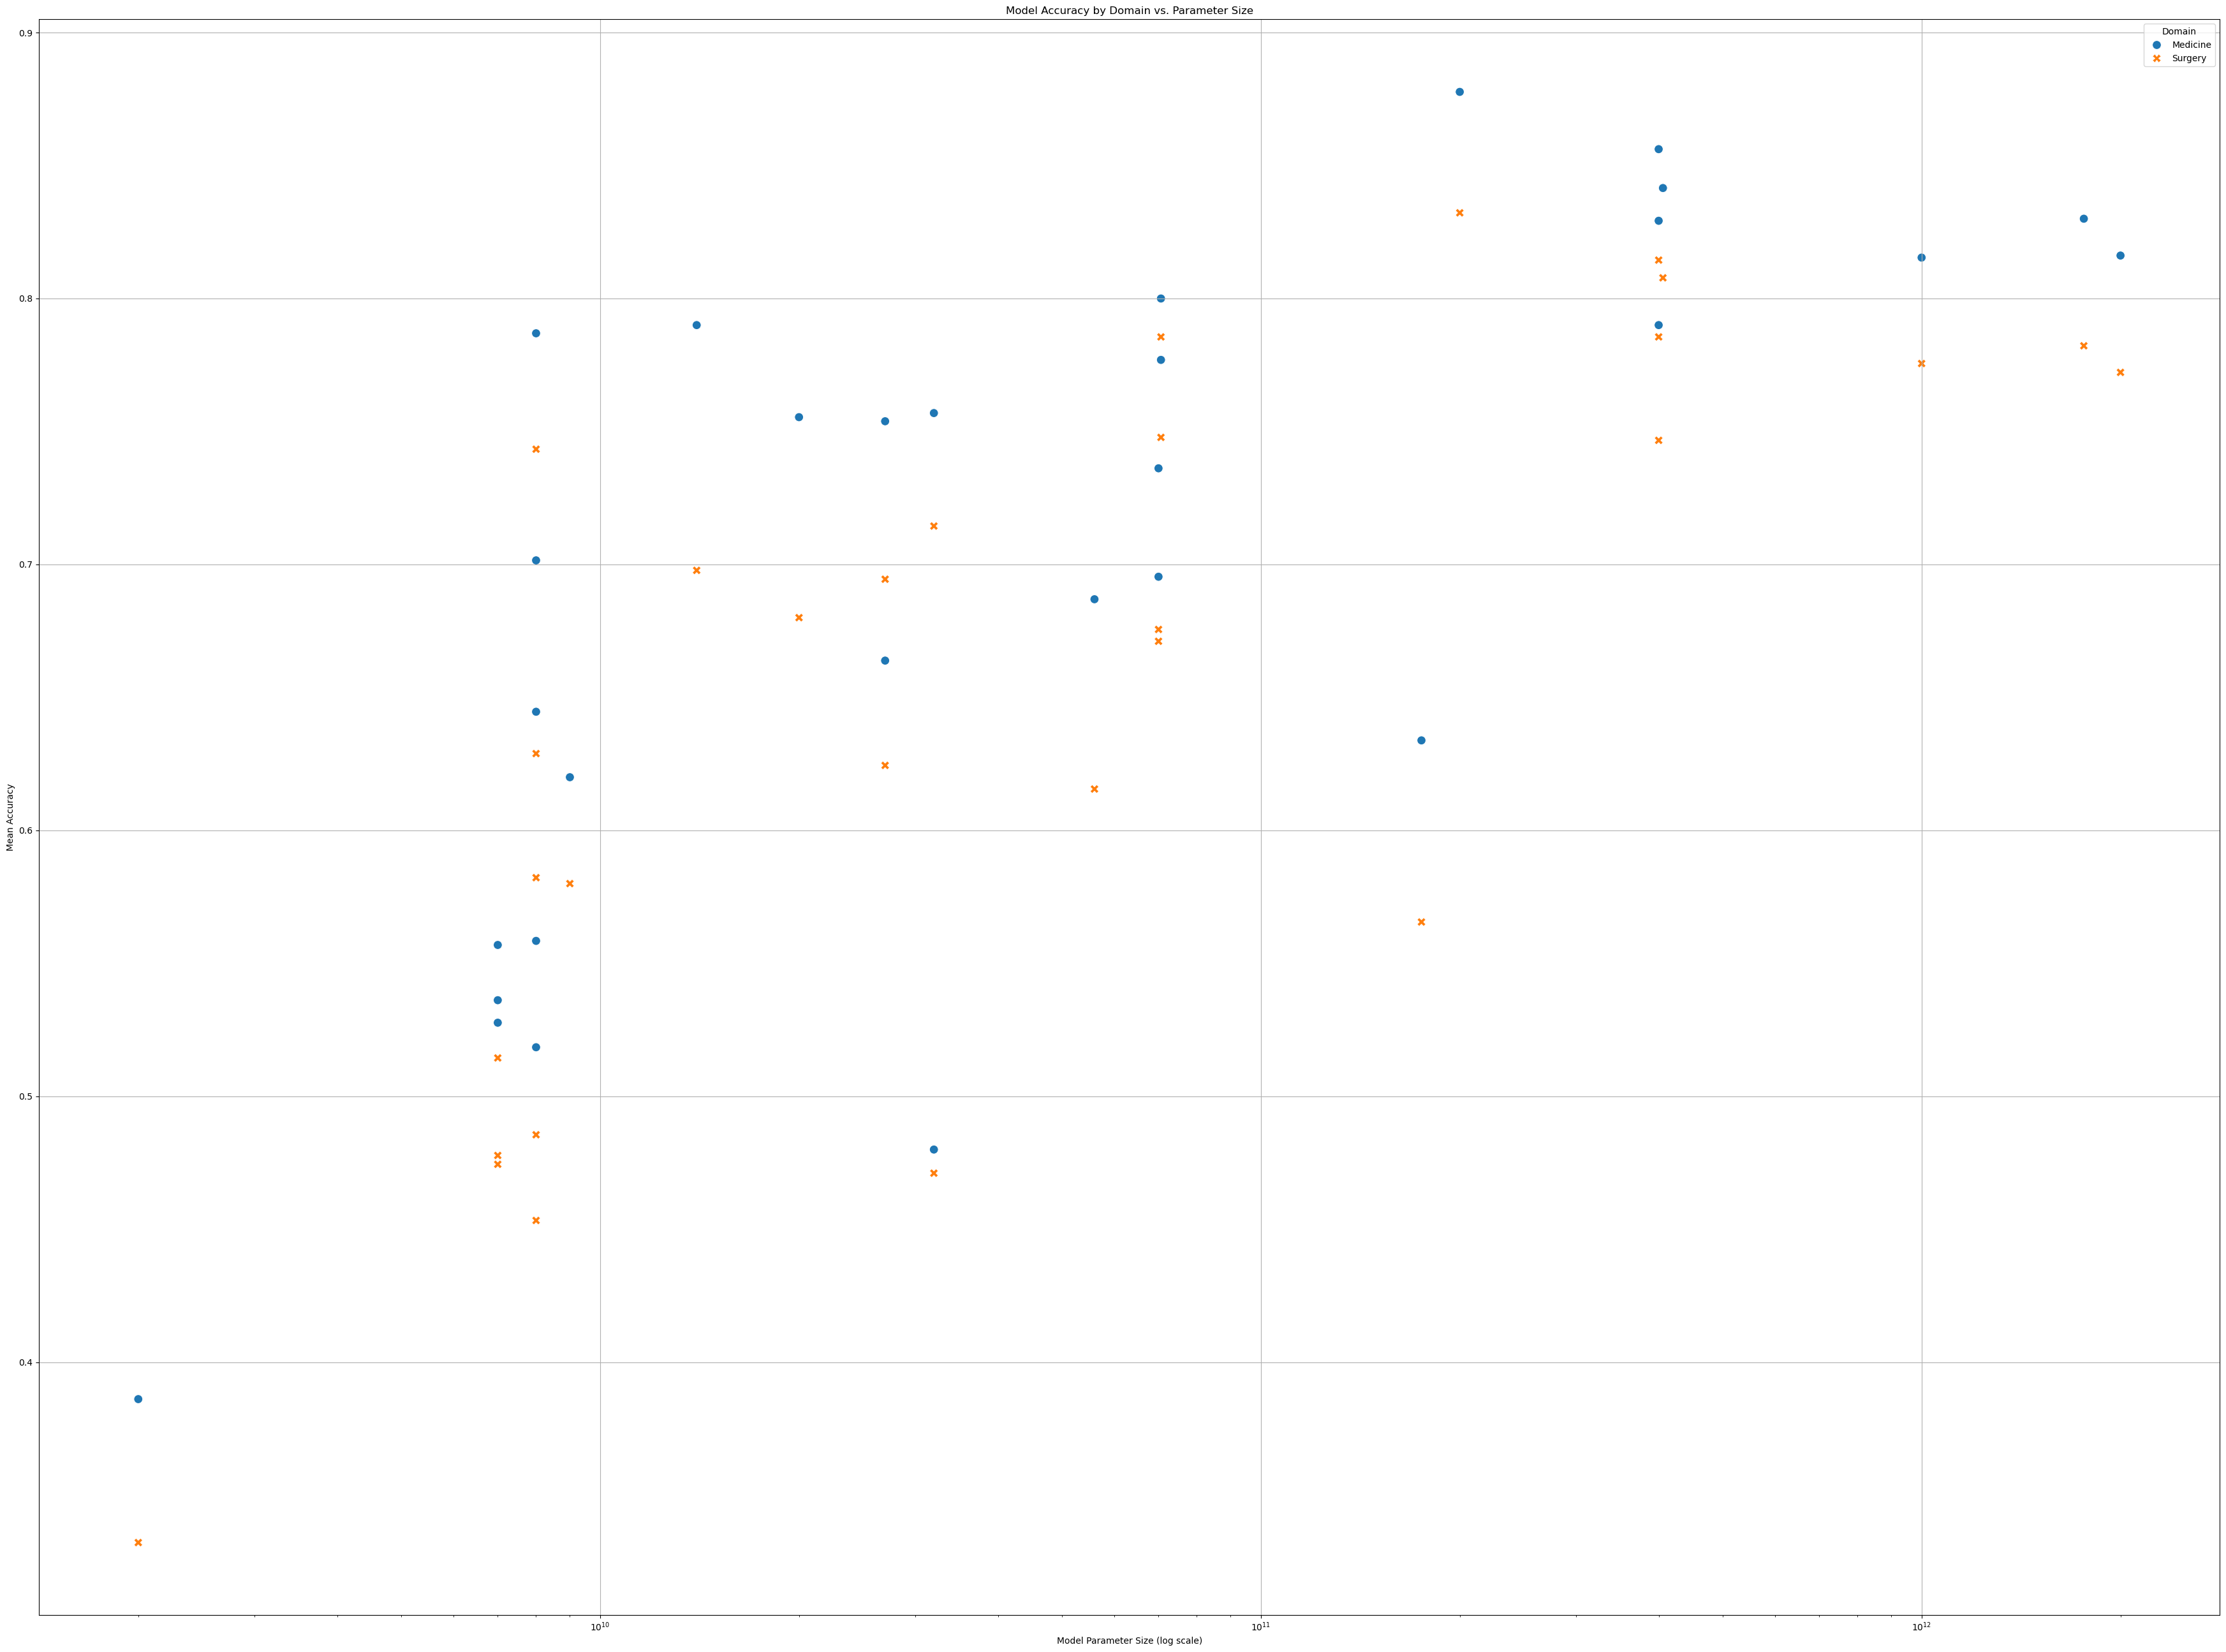

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(35,26))
sns.scatterplot(
    data=df_plot,
    x="Parameter Size",
    y="accuracy",
    hue="Domain",
    style="Domain",
    s=100
)
plt.xscale("log")
plt.xlabel("Model Parameter Size (log scale)")
plt.ylabel("Mean Accuracy")
plt.title("Model Accuracy by Domain vs. Parameter Size")
plt.grid(True)
plt.tight_layout()
plt.show()


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

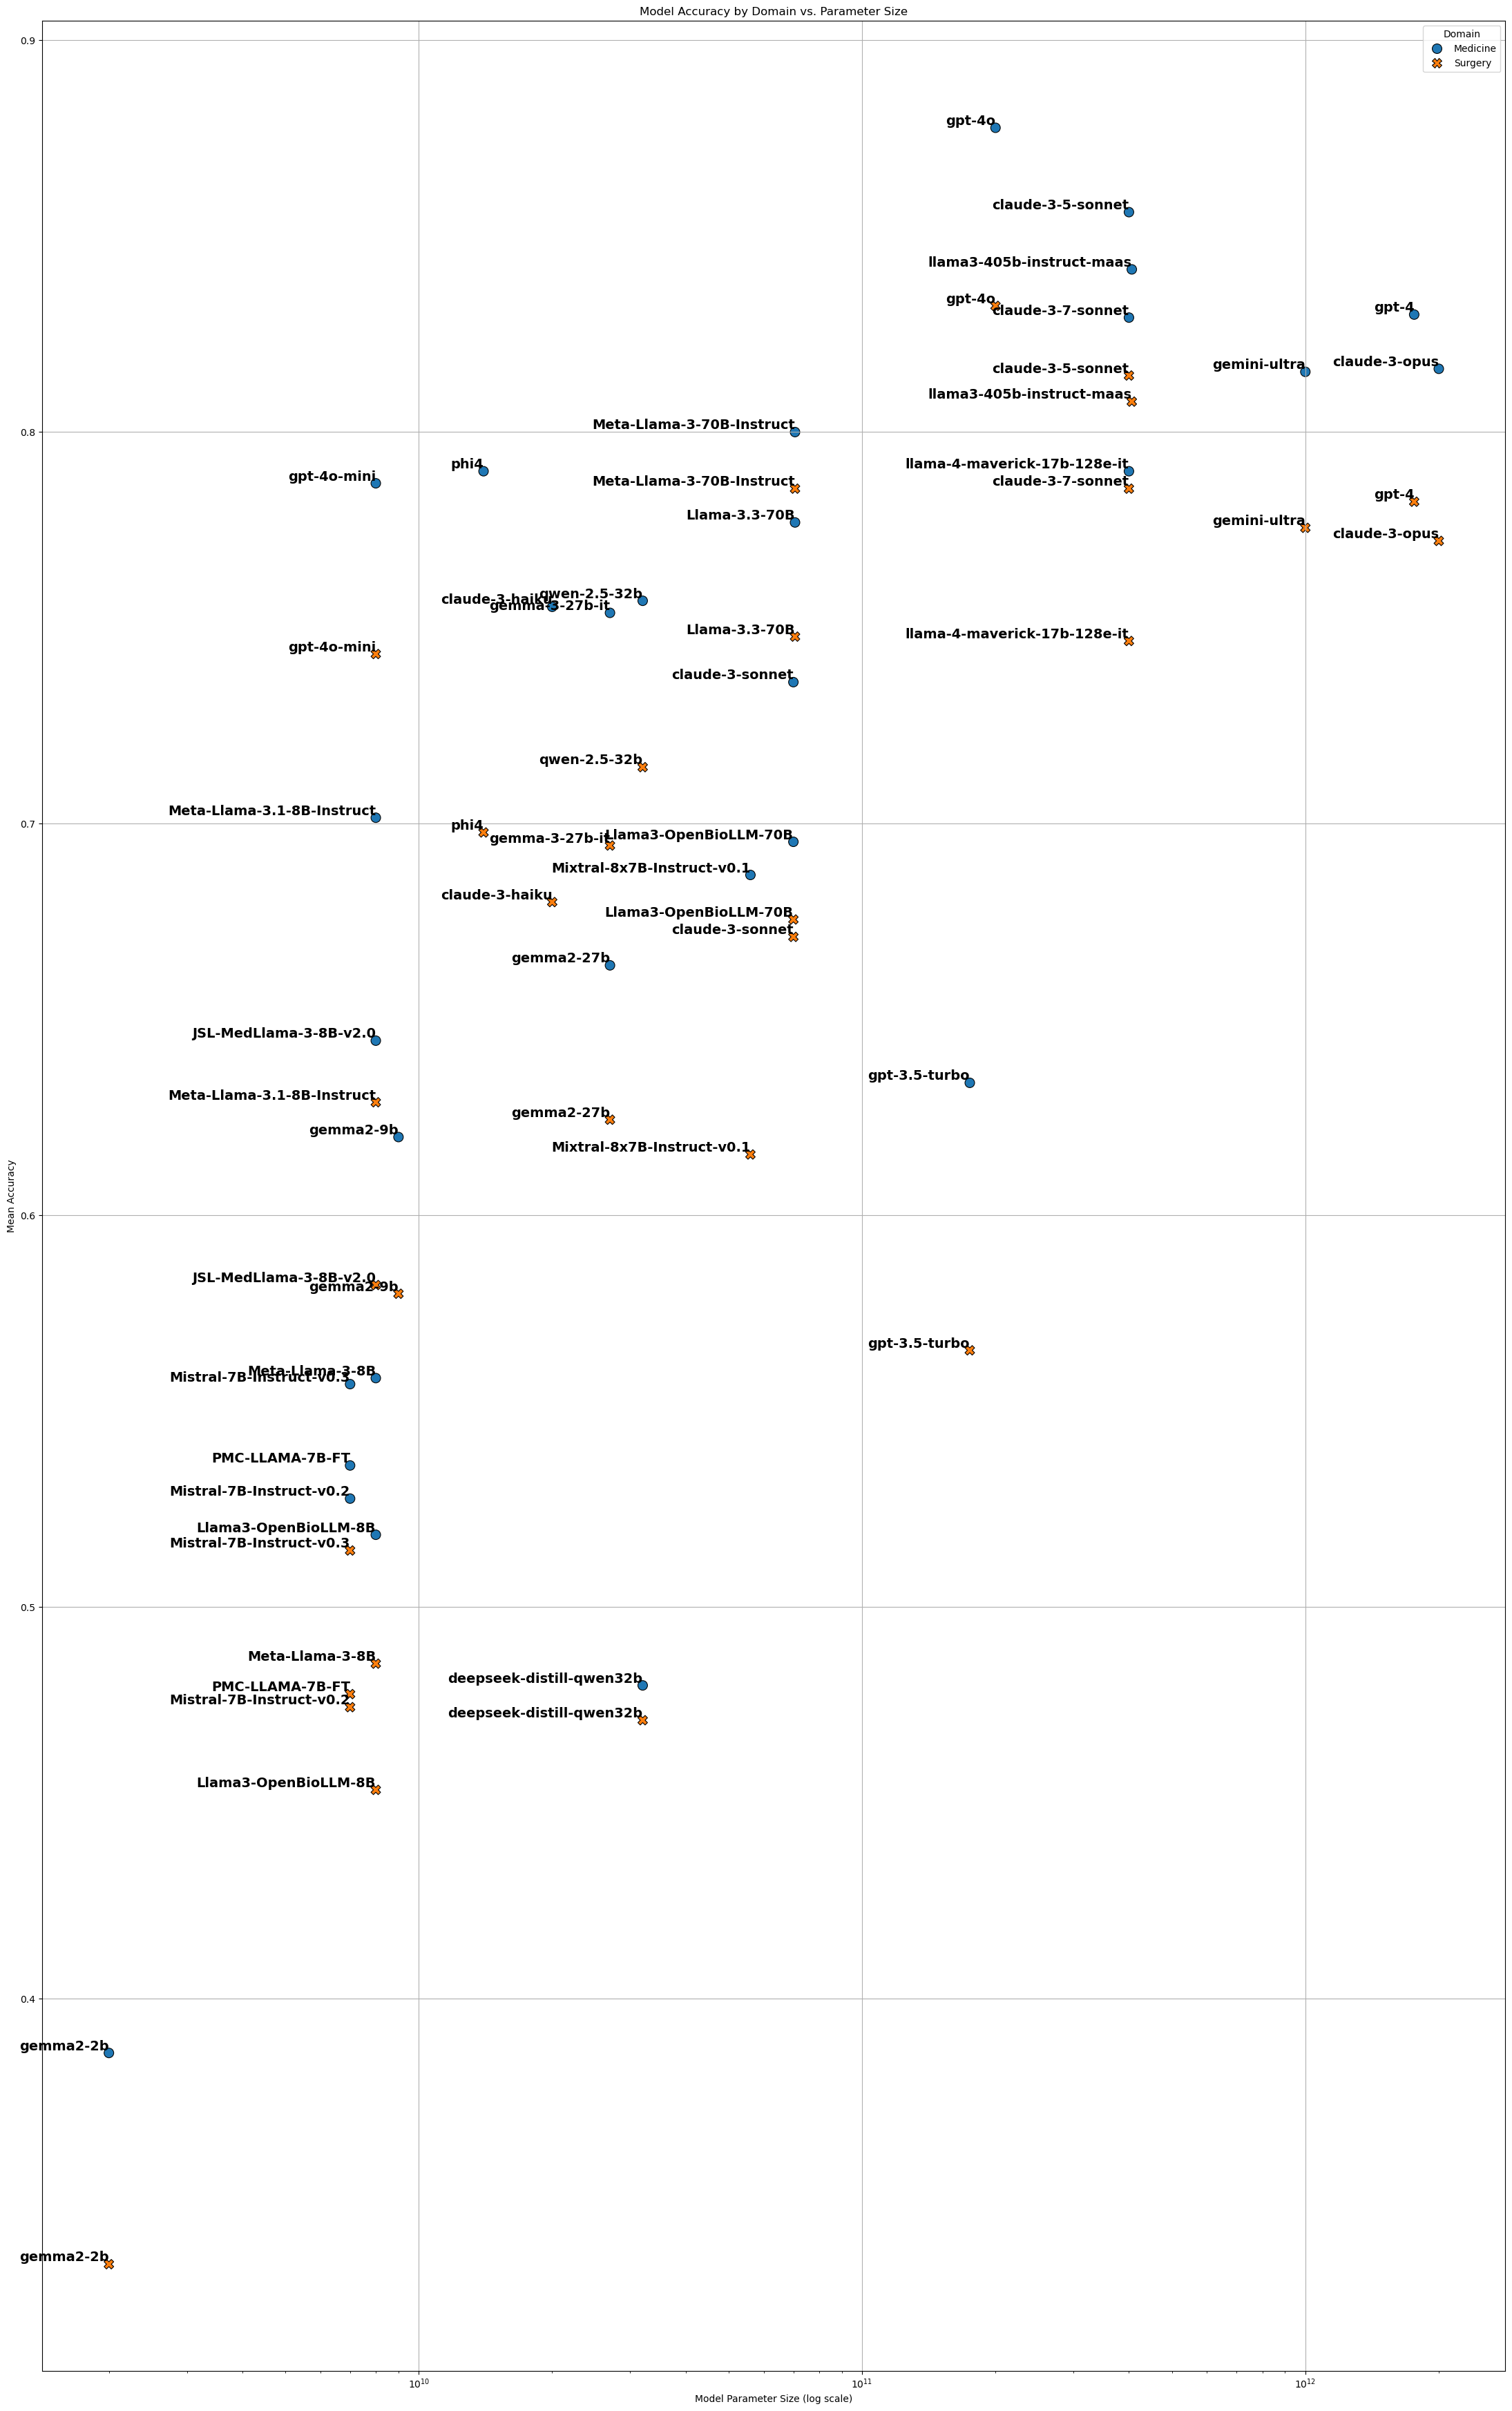

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatterplot
plt.figure(figsize=(22, 35))
sns.scatterplot(
    data=df_plot,
    x="Parameter Size",
    y="accuracy",
    hue="Domain",
    style="Domain",
    s=100,
    edgecolor="black"
)

# Use log scale for parameter size
plt.xscale("log")
plt.xlabel("Model Parameter Size (log scale)")
plt.ylabel("Mean Accuracy")
plt.title("Model Accuracy by Domain vs. Parameter Size",fontsize=12)
plt.grid(True)

# Add model name labels to each point
for _, row in df_plot.iterrows():
    plt.text(
        row["Parameter Size"], 
        row["accuracy"], 
        row["model_name"], 
        fontsize=14, 
        fontweight='bold', 
        ha='right', 
        va='bottom'
    )

plt.tight_layout()
plt.savefig("acc_dom_size.jpg", bbox_inches='tight')
plt.show()


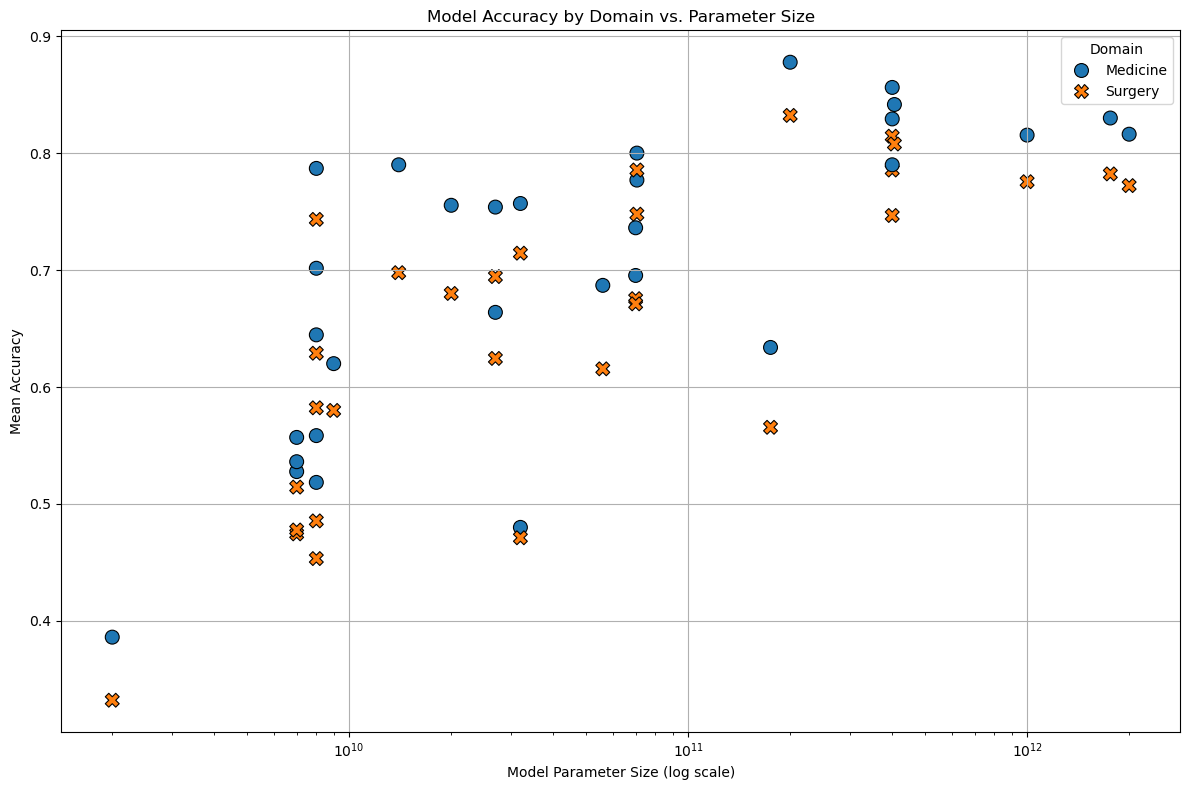

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_plot,
    x="Parameter Size",
    y="accuracy",
    hue="Domain",
    style="Domain",
    s=100,
    edgecolor="black"
)

plt.xscale("log")
plt.xlabel("Model Parameter Size (log scale)")
plt.ylabel("Mean Accuracy")
plt.title("Model Accuracy by Domain vs. Parameter Size")
plt.grid(True)

# Create text objects for each label
# texts = []
# for _, row in df_plot.iterrows():
#     texts.append(plt.text(
#         row["Parameter Size"], 
#         row["accuracy"], 
#         row["model_name"], 
#         fontsize=8, 
#         fontweight='bold', 
#         ha='right', 
#         va='bottom'
#     ))

# # Adjust text to minimize overlaps
# adjust_text(texts)

plt.tight_layout()
plt.show()


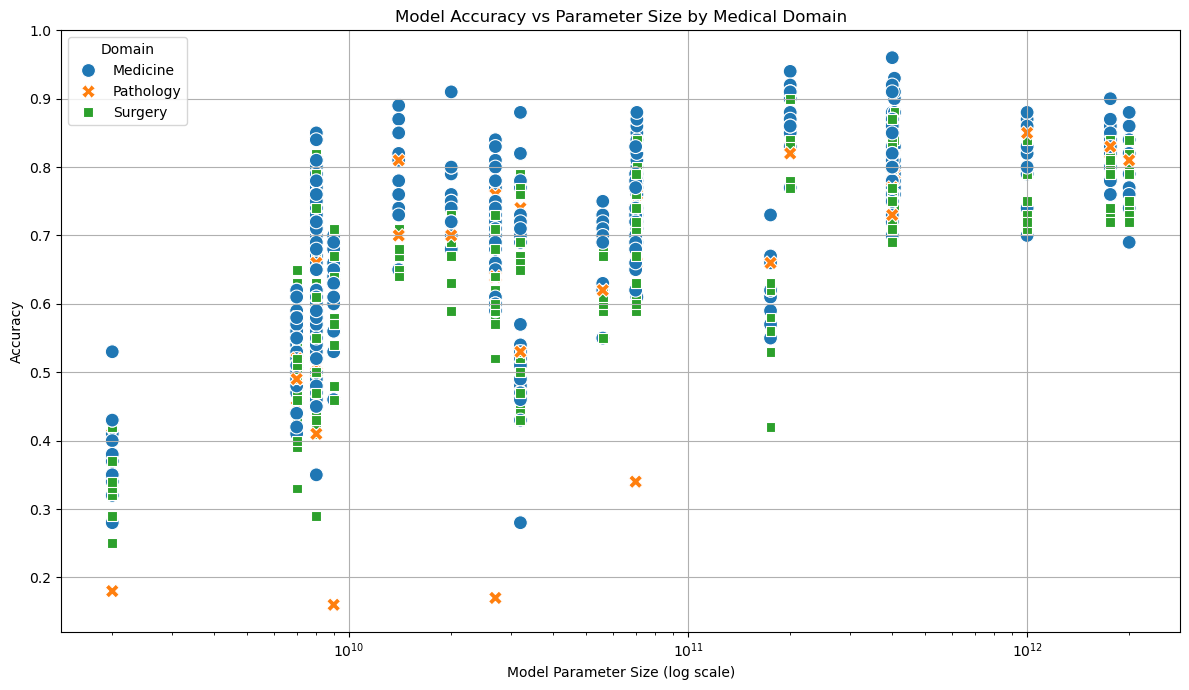

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Melt the accuracy table to long format (for easy plotting)
df_long = df_accuracy.melt(id_vars=["Specialty", "Domain"], 
                           var_name="model_name", 
                           value_name="accuracy")

# Merge with parameter sizes
df_merged = df_long.merge(df_params, on="model_name", how="inner")

# Convert param_size to numeric (in case it's not already)
df_merged["Parameter Size"] = pd.to_numeric(df_merged["Parameter Size"])

# Plot: Accuracy vs Param Size (log scale), colored by Domain
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, 
                x="Parameter Size", 
                y="accuracy", 
                hue="Domain", 
                style="Domain",
                s=100)

plt.xscale("log")
plt.xlabel("Model Parameter Size (log scale)")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs Parameter Size by Medical Domain")
plt.grid(True)
plt.legend(title="Domain")
plt.tight_layout()
plt.show()


In [24]:
df_merged.head()

,Specialty,Domain,model_name,accuracy,Parameter Size
0,Rheumatology,Medicine,gpt-4o,0.94,2.000000e+11
1,Nephrology,Medicine,gpt-4o,0.92,2.000000e+11
2,Endocrinology,Medicine,gpt-4o,0.90,2.000000e+11
3,Gastroenterology,Medicine,gpt-4o,0.91,2.000000e+11
4,Other,Medicine,gpt-4o,0.91,2.000000e+11


In [9]:
d1.columns

Index(['Specialty', 'Domain', 'o1', 'gpt-4o', 'claude-3-5-sonnet',
       'llama3-405b-instruct-maas', 'gpt-4', 'Meta-Llama-3-70B-Instruct',
       'claude-3-opus', 'gemini-ultra', 'claude-3-7-sonnet',
       'gemini-2.0-flash', 'gemini-2.0-pro-exp', 'gpt-4o-mini',
       'llama-4-maverick-17b-128e-it', 'phi4', 'claude-3-haiku',
       'qwen-2.5-32b', 'Llama-3.3-70B', 'claude-3-sonnet',
       'Phi-3-medium-128k-instruct', 'gemma-3-27b-it',
       'Mixtral-8x7B-Instruct-v0.1', 'Phi-3-mini-4k-instruct',
       'gemini-pro-1.5', 'Meta-Llama-3.1-8B-Instruct',
       'Phi-3-mini-128k-instruct', 'gemma2-27b', 'Llama3-OpenBioLLM-70B',
       'JSL-MedLlama-3-8B-v2.0', 'phi-4-mini-4k-instruct',
       'Mistral-7B-Instruct-v0.3', 'gemma2-9b', 'gpt-3.5-turbo', 'meditron',
       'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2', 'Meta-Llama-3-8B',
       'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b'],
      dtype='object')

In [ ]:
model_params{'o1', 'gpt-4o', 'claude-3-5-sonnet',
'llama3-405b-instruct-maas', 'gpt-4', 'Meta-Llama-3-70B-Instruct',
'claude-3-opus', 'gemini-ultra', 'claude-3-7-sonnet',
'gemini-2.0-flash', 'gemini-2.0-pro-exp', 'gpt-4o-mini',
'llama-4-maverick-17b-128e-it', 'phi4', 'claude-3-haiku',
'qwen-2.5-32b', 'Llama-3.3-70B', 'claude-3-sonnet',
'Phi-3-medium-128k-instruct', 'gemma-3-27b-it',
'Mixtral-8x7B-Instruct-v0.1', 'Phi-3-mini-4k-instruct',
'gemini-pro-1.5', 'Meta-Llama-3.1-8B-Instruct',
'Phi-3-mini-128k-instruct', 'gemma2-27b', 'Llama3-OpenBioLLM-70B',
'JSL-MedLlama-3-8B-v2.0', 'phi-4-mini-4k-instruct',
'Mistral-7B-Instruct-v0.3', 'gemma2-9b', 'gpt-3.5-turbo', 'meditron',
'PMC-LLAMA-7B-FT', 'Mistral-7B-Instruct-v0.2', 'Meta-Llama-3-8B',
'Llama3-OpenBioLLM-8B', 'deepseek-distill-qwen32b', 'gemma2-2b'}

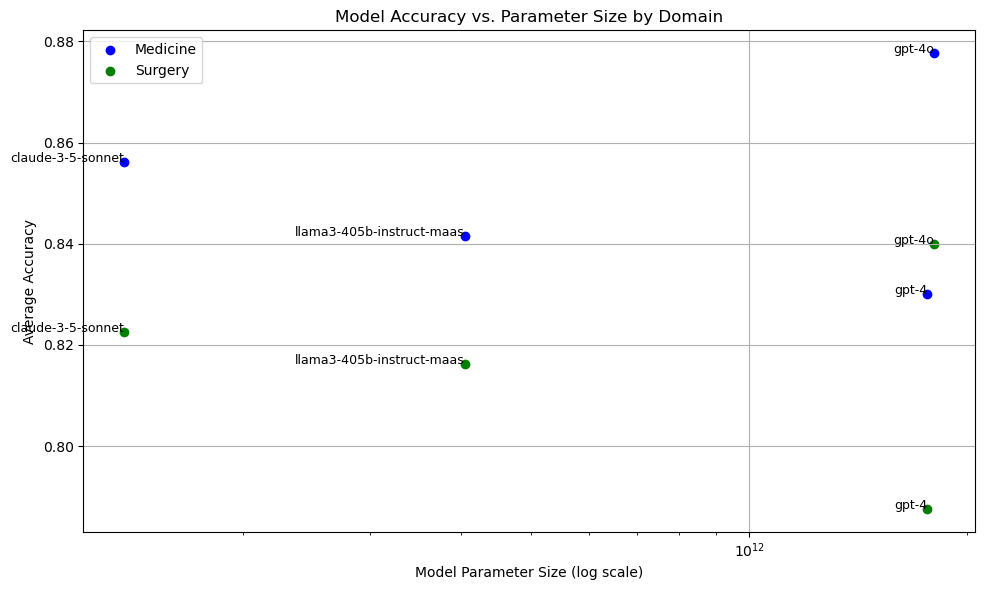

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Define model parameter sizes
model_params = {
    'gpt-4': 1.76e12,
    'gpt-4o': 1.8e12,
    'claude-3-5-sonnet': 137e9,
    'llama3-405b-instruct-maas': 405e9
}

# Calculate average accuracies for each domain and model
domains = ['Medicine', 'Surgery']
avg_accuracies = {domain: {} for domain in domains}

for domain in domains:
    domain_df = df[df['Domain'] == domain]
    for model in model_params.keys():
        avg_accuracy = domain_df[model].mean()
        avg_accuracies[domain][model] = avg_accuracy

# Plotting
plt.figure(figsize=(10, 6))

for domain, color in zip(domains, ['blue', 'green']):
    x = [model_params[model] for model in model_params]
    y = [avg_accuracies[domain][model] for model in model_params]
    plt.scatter(x, y, label=domain, color=color)
    for i, model in enumerate(model_params):
        plt.text(x[i], y[i], model, fontsize=9, ha='right')

plt.xscale('log')
plt.xlabel('Model Parameter Size (log scale)')
plt.ylabel('Average Accuracy')
plt.title('Model Accuracy vs. Parameter Size by Domain')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
